# Day 19 - Seaborn Continued (Part 2)

---

**What you will learn today:**

- Categorical plots: stripplot, swarmplot, boxplot, violinplot, barplot, pointplot, countplot
- catplot: the figure-level wrapper for all categorical plots
- Regression plots: regplot, lmplot, residplot
- FacetGrid: manual grid creation with full control
- Pairplot: scatter matrix shortcut for EDA
- PairGrid: customizable version of pairplot
- Jointplot and JointGrid: bivariate with marginals
- Seaborn built-in datasets overview

---

**Datasets today:**
- `sns.load_dataset('titanic')` for categorical and regression plots
- `sns.load_dataset('iris')` for grid plots
- `sns.load_dataset('tips')` for additional examples

---

**Why this matters for interviews:**

When a data science interviewer says "show me your EDA process", they expect you to pull out pairplot, boxplot, and violinplot immediately. These are the standard tools for understanding a new dataset. If you can do EDA on Titanic and Iris fluently, you are ready for any data science interview.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('day19_charts', exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

# Load all datasets we will use today
tips    = sns.load_dataset('tips')
titanic = sns.load_dataset('titanic')
iris    = sns.load_dataset('iris')
planets = sns.load_dataset('planets')

print('All datasets loaded.')
print(f'tips    : {tips.shape}')
print(f'titanic : {titanic.shape}')
print(f'iris    : {iris.shape}')
print(f'planets : {planets.shape}')

All datasets loaded.
tips    : (244, 7)
titanic : (891, 15)
iris    : (150, 5)
planets : (1035, 6)


---

# Part 1: Built-in Seaborn Datasets

Before plotting, always understand your data. Here is what each dataset contains and why each one is useful for practice.

---

## Tips Dataset

Restaurant bills and tips. 244 rows.
Columns: total_bill, tip, sex, smoker, day, time, size.
Good for: scatter, line, histogram, KDE, heatmap.

## Titanic Dataset

Passenger survival data from the Titanic ship disaster. 891 rows.
Columns: survived, pclass (passenger class 1/2/3), sex, age, fare, embarked, and many more.
Good for: categorical plots, regression, EDA, binary classification visualization.
Why it matters: Titanic is THE classic dataset for data science interviews. Knowing how to EDA it visually is expected.

## Iris Dataset

Flower measurements for 3 iris species. 150 rows.
Columns: sepal_length, sepal_width, petal_length, petal_width, species.
Good for: pairplot, PairGrid, KDE, scatter, clustering visualization.
Why it matters: Iris is the classic machine learning dataset. The species are separable in petal measurements - any good visualization reveals this. Showing this in an interview demonstrates ML intuition.

## Planets Dataset

Exoplanets discovered by astronomers. 1035 rows.
Columns: method (discovery method), number, orbital_period, mass, distance, year.
Good for: time-series, log-scale plots, categorical comparisons.

In [2]:
# Quick exploration of Titanic - always do this before plotting
print('TITANIC DATASET')
print('='*40)
print(titanic.head())
print()
print('Data types:')
print(titanic.dtypes)
print()
print('Missing values:')
print(titanic.isnull().sum())
print()
print('Survival rate:', titanic['survived'].mean().round(3))
print('Survival by class:')
print(titanic.groupby('pclass')['survived'].mean().round(3))

TITANIC DATASET
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         objec

In [3]:
print('IRIS DATASET')
print('='*40)
print(iris.head())
print()
print('Species count:')
print(iris['species'].value_counts())
print()
print('Summary:')
print(iris.describe())

IRIS DATASET
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Summary:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7

---

# Part 2: Categorical Plots

## The Big Picture: What is a Categorical Plot?

A categorical plot has one categorical variable on one axis (like pclass: 1, 2, 3) and a numerical variable on the other axis (like age or fare). The chart shows how the numerical variable is distributed within each category.

Seaborn has seven categorical plot types. They all answer the same question - "how does this number differ across categories?" - but they show different amounts of detail.

From least to most detail:
1. barplot - shows only the mean (one bar per category)
2. pointplot - shows mean + confidence interval (one point per category)
3. boxplot - shows median, quartiles, outliers (5-number summary)
4. violinplot - shows full distribution shape (KDE + boxplot)
5. stripplot - shows all individual points
6. swarmplot - shows all individual points, non-overlapping
7. countplot - counts occurrences (does not need a y variable)

In practice, use:
- boxplot or violinplot for distributions (most common in EDA)
- barplot for simple comparisons in reports
- swarmplot when you want to see every individual point (small datasets only)
- countplot for frequency of categorical values

## 2.1 Stripplot - All Individual Points, Possibly Overlapping

A stripplot plots every individual data point as a dot on a categorical axis. If there are 200 people in class 3, you see 200 dots.

The problem: many dots fall at the same position and overlap, making it hard to see density.

The solution: `jitter=True`. Jitter adds a tiny random horizontal shift to each dot so they spread out and you can see how many there are in each region.

When to use: Small to medium datasets where you want to see every individual point, not just a summary. Works well when overlaid on top of a boxplot.

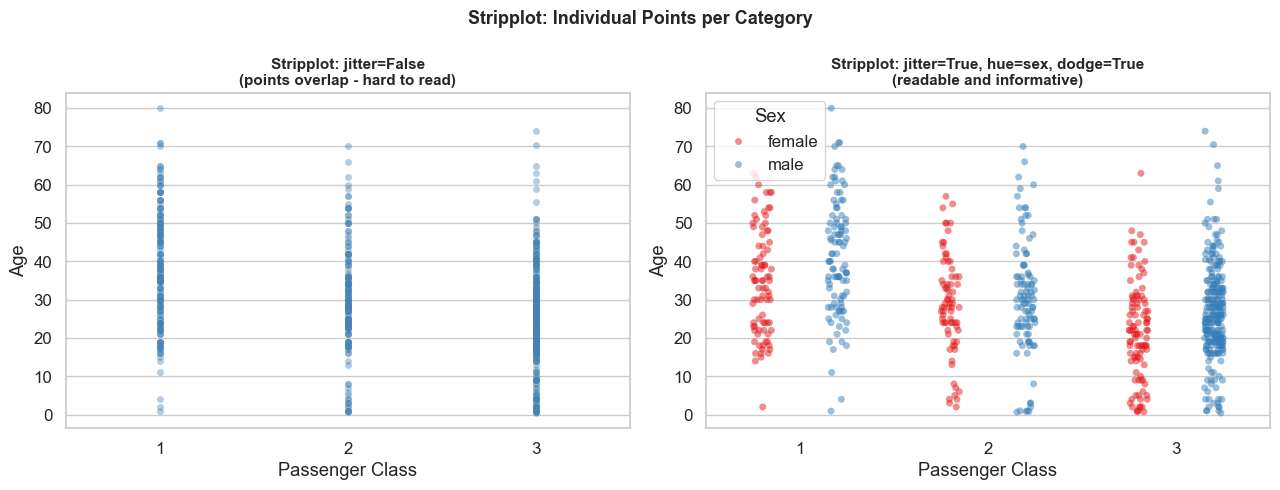

Key parameters: jitter=, dodge=, alpha=


In [4]:
# STRIPPLOT: Age distribution by passenger class on Titanic

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: jitter=False - all points on the same vertical line, completely overlapping
sns.stripplot(
    data=titanic,
    x='pclass',
    y='age',
    jitter=False,        # no spread - you lose information due to overlap
    alpha=0.4,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Stripplot: jitter=False\n(points overlap - hard to read)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Age')

# Right: jitter=True - small random horizontal shift, easier to read density
sns.stripplot(
    data=titanic,
    x='pclass',
    y='age',
    hue='sex',           # color by sex - now you see sex differences within each class
    jitter=True,
    alpha=0.5,
    dodge=True,          # separate male/female side by side within each class
    palette='Set1',
    ax=axes[1]
)
axes[1].set_title('Stripplot: jitter=True, hue=sex, dodge=True\n(readable and informative)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Age')
axes[1].legend(title='Sex')

plt.suptitle('Stripplot: Individual Points per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/1_stripplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key parameters: jitter=, dodge=, alpha=')

## 2.2 Swarmplot - All Points, Non-Overlapping (Beehive Shape)

Swarmplot is like stripplot but smarter. Instead of random jitter, it places each point at the exact position that prevents overlap with all other points.

The result is a "beehive" or "beeswarm" shape. Wide sections = many data points there. Narrow sections = few points. You can see the full distribution shape while also seeing every individual point.

The cost: Swarmplot is much slower than stripplot because it has to calculate non-overlapping positions for every point. With more than 500 points, it becomes slow and the plot becomes crowded.

Rule: use swarmplot for datasets under 200-300 points. For larger datasets, use violinplot instead.

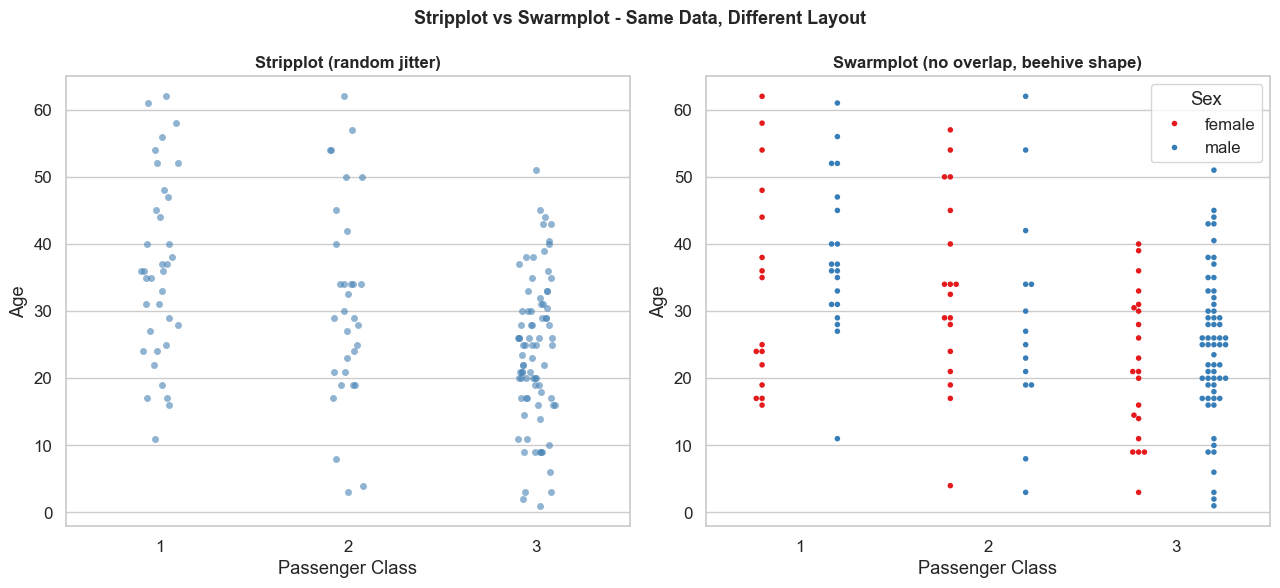

Swarmplot insight: wide sections = many people of that age in that class


In [5]:
# SWARMPLOT vs STRIPPLOT comparison
# Use a smaller subset of titanic to keep swarmplot fast
titanic_small = titanic.dropna(subset=['age']).sample(150, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: stripplot with jitter
sns.stripplot(data=titanic_small, x='pclass', y='age',
              jitter=True, alpha=0.6, color='steelblue', ax=axes[0])
axes[0].set_title('Stripplot (random jitter)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Age')

# Right: swarmplot - no overlap, beehive shape
sns.swarmplot(
    data=titanic_small,
    x='pclass',
    y='age',
    hue='sex',
    dodge=True,          # separate by hue within each category
    palette='Set1',
    size=4,              # size of each dot
    ax=axes[1]
)
axes[1].set_title('Swarmplot (no overlap, beehive shape)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Age')
axes[1].legend(title='Sex', loc='upper right')

plt.suptitle('Stripplot vs Swarmplot - Same Data, Different Layout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/2_swarmplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Swarmplot insight: wide sections = many people of that age in that class')

## 2.3 Boxplot - The 5-Number Summary

The boxplot is the workhorse of EDA. It shows five statistics at once for each category.

### What the 5-Number Summary Is:

Given a list of numbers, the 5-number summary is:
1. Minimum - the smallest value
2. Q1 (25th percentile) - 25% of values are below this
3. Median (50th percentile) - the middle value, half above and half below
4. Q3 (75th percentile) - 75% of values are below this
5. Maximum - the largest value

### How the Boxplot Draws This:

- The box spans from Q1 to Q3. This range is called the IQR (Interquartile Range).
- The line inside the box is the median.
- The whiskers extend from Q1 down to Q1 - 1.5*IQR and from Q3 up to Q3 + 1.5*IQR.
- Any point beyond the whiskers is drawn as an individual dot: these are OUTLIERS.

### What You Learn from a Boxplot:

- Tall box = high variability (data is spread out)
- Short box = low variability (data is concentrated)
- Median close to top of box = distribution is skewed downward
- Median close to bottom of box = distribution is skewed upward
- Many outlier dots = heavy-tailed distribution
- Comparing boxes across categories = instantly see which group has higher/lower values

C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\2891231787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


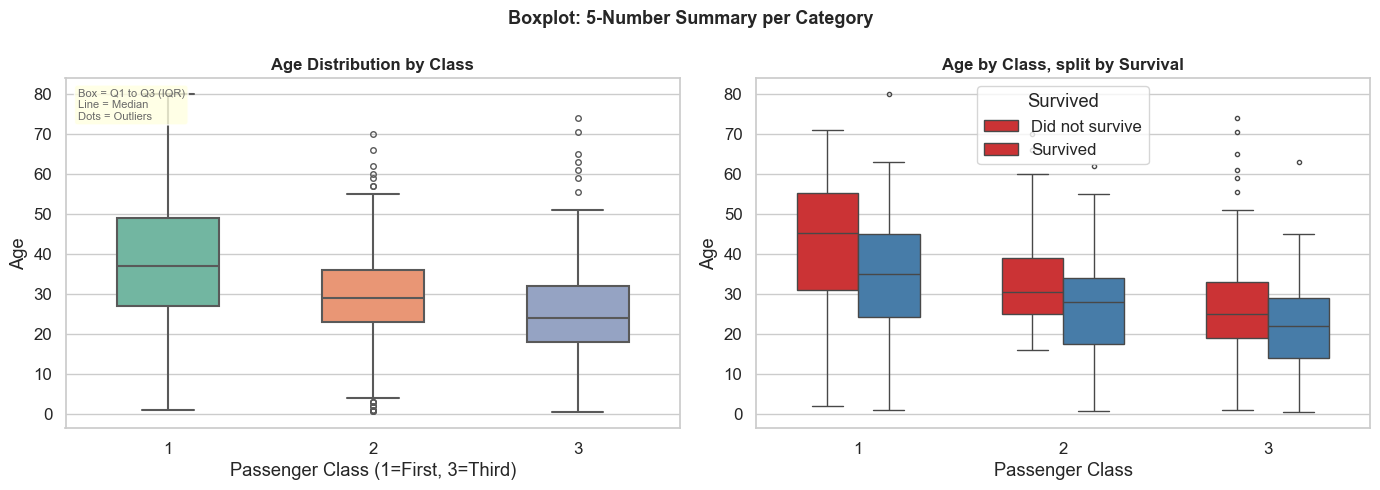

In [6]:
# BOXPLOT 1: Age distribution by passenger class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple boxplot
sns.boxplot(
    data=titanic,
    x='pclass',
    y='age',
    palette='Set2',
    width=0.5,           # width of each box
    fliersize=4,         # size of outlier dots
    linewidth=1.5,
    ax=axes[0]
)
axes[0].set_title('Age Distribution by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class (1=First, 3=Third)')
axes[0].set_ylabel('Age')

# Add annotation explaining box components to first category
axes[0].text(0.02, 0.97,
    'Box = Q1 to Q3 (IQR)\nLine = Median\nDots = Outliers',
    transform=axes[0].transAxes, fontsize=8, va='top', color='dimgray',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# Boxplot with hue - splits each class into survived vs not survived
sns.boxplot(
    data=titanic,
    x='pclass',
    y='age',
    hue='survived',      # one box per class per survival status
    palette='Set1',
    width=0.6,
    fliersize=3,
    ax=axes[1]
)
axes[1].set_title('Age by Class, split by Survival', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Age')
axes[1].legend(title='Survived', labels=['Did not survive', 'Survived'])

plt.suptitle('Boxplot: 5-Number Summary per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

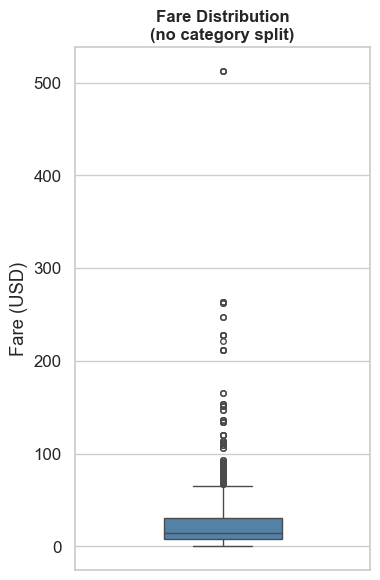

Observation: Fare is heavily right-skewed. Median is low but there are huge outliers.
This means most passengers paid little, but a few paid enormously (first class).


In [7]:
# BOXPLOT on a single column (no x= category)
# Shows the overall distribution of one variable

fig, ax = plt.subplots(figsize=(4, 6))

sns.boxplot(
    data=titanic,
    y='fare',            # only y= - no x= category
    color='steelblue',
    width=0.4,
    fliersize=4,
    ax=ax
)

ax.set_title('Fare Distribution\n(no category split)', fontsize=12, fontweight='bold')
ax.set_ylabel('Fare (USD)')

plt.tight_layout()
plt.show()
print('Observation: Fare is heavily right-skewed. Median is low but there are huge outliers.')
print('This means most passengers paid little, but a few paid enormously (first class).')

## 2.4 Violinplot - Boxplot + KDE Combined

A violinplot combines the 5-number summary of a boxplot with the smooth distribution curve of a KDE.

### What You See in a Violinplot:

- The outer shape (the violin body) is a mirrored KDE curve. Wide = many data points there. Narrow = few.
- Inside the violin: a thin box showing the IQR (Q1 to Q3).
- The white dot in the center = the median.
- The thin vertical line inside = the whisker range (like boxplot whiskers).

### Violinplot vs Boxplot: When to Use Which:

Use boxplot when:
- You have a small number of data points (KDE does not work well with few points)
- You specifically need to communicate the 5-number summary to a non-technical audience
- The distribution is roughly normal or symmetric

Use violinplot when:
- You have enough data (100+ points per category)
- The distribution might be bimodal or unusual (violinplot reveals this; boxplot hides it)
- You want to compare distribution shapes, not just medians

### The split=True Parameter:

When you have a hue variable with exactly 2 categories, `split=True` (sometimes called `inner_kws` or `split` depending on version) shows each hue on one side of the violin. Left side = category 1. Right side = category 2. This is extremely space-efficient and makes comparison easy.

C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\51793734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


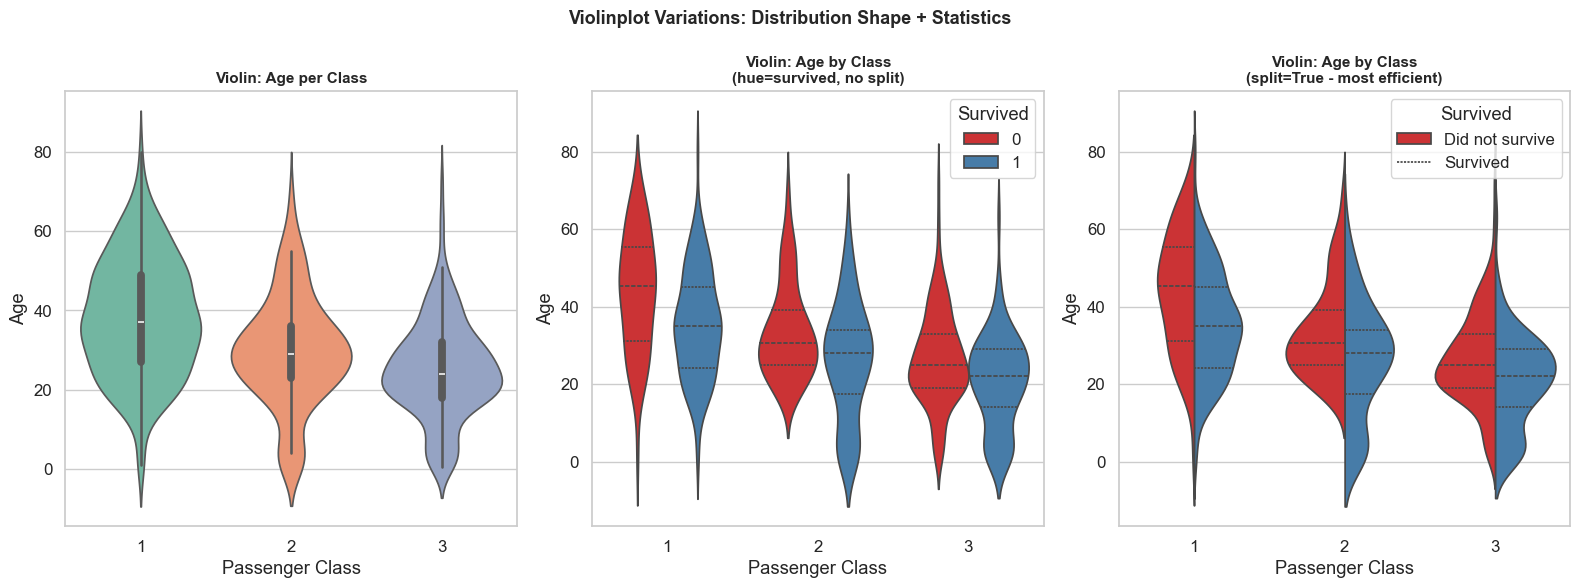

Observation from split violin:
Class 1: Survivors and non-survivors have similar age distribution.
Class 3: Survivors are slightly younger than non-survivors.


In [8]:
# VIOLINPLOT: Age distribution by survival status

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Left: regular violinplot
sns.violinplot(
    data=titanic,
    x='pclass',
    y='age',
    palette='Set2',
    inner='box',         # what to show inside: 'box', 'quart', 'point', 'stick', None
    ax=axes[0]
)
axes[0].set_title('Violin: Age per Class', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Age')

# Middle: violinplot with hue, NO split
# Each class now has two violins side by side (survived=0 and survived=1)
sns.violinplot(
    data=titanic.dropna(subset=['age']),
    x='pclass',
    y='age',
    hue='survived',
    palette='Set1',
    inner='quartile',    # shows quartile lines inside violin
    dodge=True,
    ax=axes[1]
)
axes[1].set_title('Violin: Age by Class\n(hue=survived, no split)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Age')
axes[1].legend(title='Survived')

# Right: split=True - left side and right side show the two hue groups
# This is the most elegant comparison: one violin, two sides
sns.violinplot(
    data=titanic.dropna(subset=['age']),
    x='pclass',
    y='age',
    hue='survived',
    split=True,          # KEY: half violin per hue group. Only works with 2 hue categories.
    palette='Set1',
    inner='quart',
    ax=axes[2]
)
axes[2].set_title('Violin: Age by Class\n(split=True - most efficient)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Passenger Class')
axes[2].set_ylabel('Age')
axes[2].legend(title='Survived', labels=['Did not survive', 'Survived'])

plt.suptitle('Violinplot Variations: Distribution Shape + Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/4_violinplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation from split violin:')
print('Class 1: Survivors and non-survivors have similar age distribution.')
print('Class 3: Survivors are slightly younger than non-survivors.')

## 2.5 Barplot - Mean with Confidence Interval

In Seaborn, `barplot` does NOT just count things. It shows the MEAN of a numerical variable for each category, with a confidence interval bar showing uncertainty.

This is different from a simple bar chart where bar height = count. Here bar height = mean of y variable.

### estimator parameter:

The `estimator` parameter controls what statistic to compute:
- `estimator=np.mean` (default) - shows the average
- `estimator=np.median` - shows the median
- `estimator=np.sum` - shows the total
- `estimator=np.max` - shows the maximum
- `estimator=len` - shows the count (makes it a count plot)

### ci parameter (confidence interval):

The thin vertical line on top of each bar is the confidence interval. It shows the range where the true population mean is likely to be (based on bootstrap resampling of the data).
- `ci=95` (default) - 95% confidence interval
- `ci=None` - removes the confidence interval bar
- `ci='sd'` - shows standard deviation instead

C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\3954650961.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\3954650961.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\3954650961.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\3954650961.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


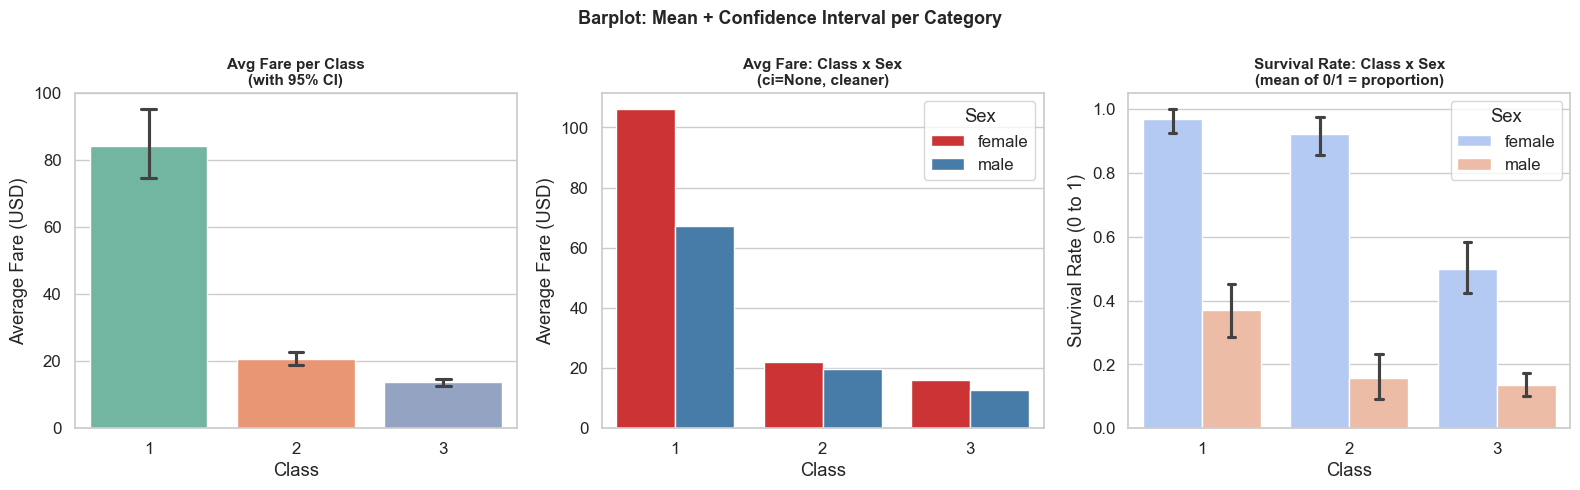

Insight: Women survived at much higher rates than men in all classes (classic Titanic finding).


In [9]:
# BARPLOT: Average fare by class and sex

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: simple barplot with default estimator (mean) and CI
sns.barplot(
    data=titanic,
    x='pclass',
    y='fare',
    palette='Set2',
    ci=95,               # 95% confidence interval (default)
    capsize=0.1,         # adds horizontal caps to the CI bars
    ax=axes[0]
)
axes[0].set_title('Avg Fare per Class\n(with 95% CI)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Average Fare (USD)')

# Middle: hue adds sex comparison within each class
sns.barplot(
    data=titanic,
    x='pclass',
    y='fare',
    hue='sex',
    palette='Set1',
    ci=None,             # remove CI bars for cleaner look
    ax=axes[1]
)
axes[1].set_title('Avg Fare: Class x Sex\n(ci=None, cleaner)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Average Fare (USD)')
axes[1].legend(title='Sex')

# Right: different estimator - survival rate per class (using mean of survived column)
# survived is 0 or 1, so mean = proportion = survival rate
sns.barplot(
    data=titanic,
    x='pclass',
    y='survived',        # 0 or 1
    hue='sex',
    palette='coolwarm',
    ci=95,
    capsize=0.1,
    ax=axes[2]
)
axes[2].set_title('Survival Rate: Class x Sex\n(mean of 0/1 = proportion)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Survival Rate (0 to 1)')
axes[2].legend(title='Sex')

plt.suptitle('Barplot: Mean + Confidence Interval per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/5_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Women survived at much higher rates than men in all classes (classic Titanic finding).')

## 2.6 Pointplot - Means Connected by Lines

Pointplot is similar to barplot but shows the mean as a point (dot) instead of a bar, and connects points with lines.

It is ideal for showing how the mean changes across ordered categories. The connecting line makes trends visually obvious.

With hue, you get multiple lines - one per group. This is the go-to for interaction effects: "does the relationship between class and survival rate differ by sex?"

The error bars are computed using bootstrapping: randomly resample the data many times, compute the mean each time, and the range of those means gives the confidence interval. This is statistically sound uncertainty quantification.

C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\3878688756.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\3878688756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(


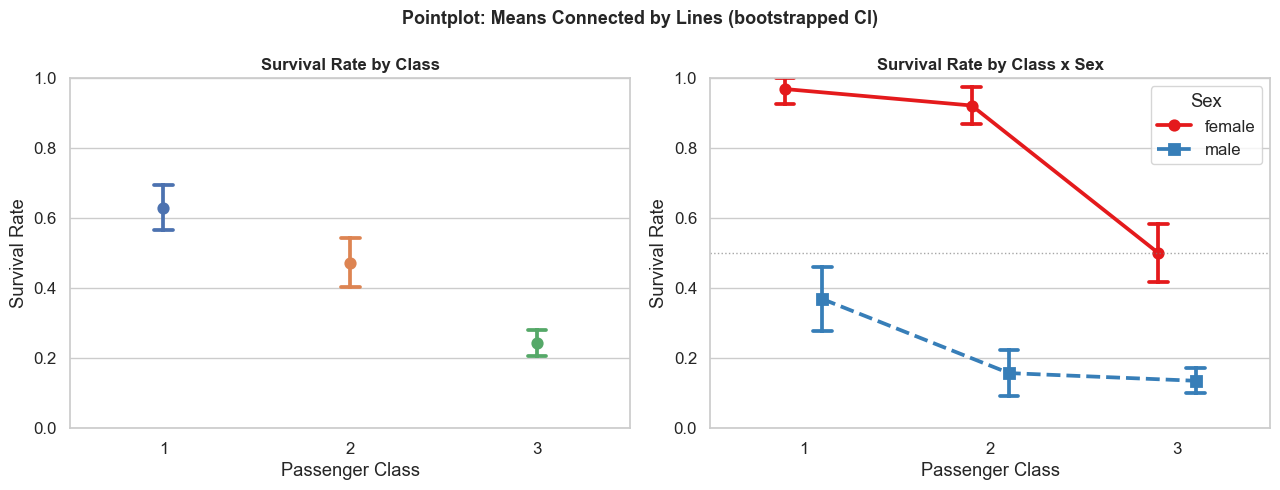

In [10]:
# POINTPLOT: Survival rate across classes, split by sex

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: survival rate per class
sns.pointplot(
    data=titanic,
    x='pclass',
    y='survived',
    palette='deep',
    markers='o',         # marker shape for each point
    linestyles='-',      # line style connecting points
    capsize=0.1,         # caps on error bars
    ci=95,
    ax=axes[0]
)
axes[0].set_title('Survival Rate by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

# Right: survival rate by class, separate lines for sex
# The lines crossing or diverging reveals interaction between class and sex
sns.pointplot(
    data=titanic,
    x='pclass',
    y='survived',
    hue='sex',           # separate lines for Male and Female
    palette='Set1',
    dodge=0.2,           # horizontal separation between male/female points
    markers=['o', 's'],  # different markers per hue
    linestyles=['-', '--'],
    capsize=0.1,
    ax=axes[1]
)
axes[1].set_title('Survival Rate by Class x Sex', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Sex')
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)

plt.suptitle('Pointplot: Means Connected by Lines (bootstrapped CI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/6_pointplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Countplot - Categorical Frequency

Countplot counts how many rows belong to each category. It is essentially a histogram for a categorical variable.

The key difference from barplot: countplot does NOT take a y= parameter. It counts automatically.

With hue, it shows the count split by a second categorical variable. This answers: "how many people in each class survived vs died?"

C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\1376514856.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


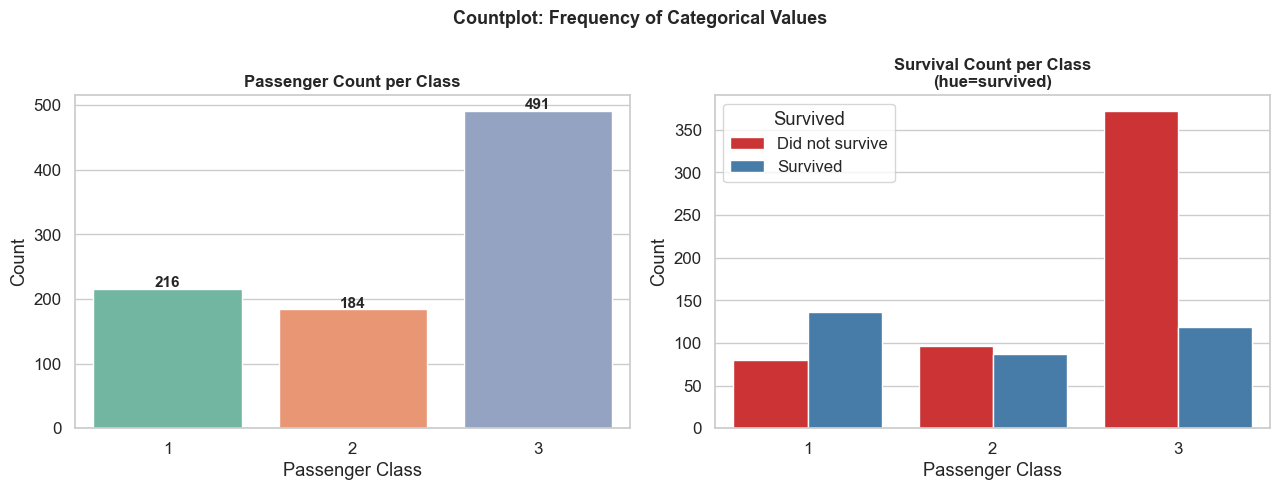

Insight: Class 3 had the most passengers but the worst survival rate.


In [11]:
# COUNTPLOT: Passenger class distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: simple count per class
sns.countplot(
    data=titanic,
    x='pclass',
    palette='Set2',
    edgecolor='white',
    linewidth=1,
    ax=axes[0]
)
axes[0].set_title('Passenger Count per Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')

# Add count labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 3),
                     ha='center', fontsize=11, fontweight='bold')

# Right: count with hue=survived
sns.countplot(
    data=titanic,
    x='pclass',
    hue='survived',      # splits each bar into survived and not survived
    palette='Set1',
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_title('Survival Count per Class\n(hue=survived)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Count')
axes[1].legend(title='Survived', labels=['Did not survive', 'Survived'])

plt.suptitle('Countplot: Frequency of Categorical Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/7_countplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Class 3 had the most passengers but the worst survival rate.')

## 2.8 catplot - Figure-Level Wrapper for All Categorical Plots

`catplot` is to categorical plots what `relplot` is to scatter and line plots. It is the figure-level function that wraps all seven categorical plot types.

The `kind=` parameter selects which plot type:
- `kind='strip'` - stripplot
- `kind='swarm'` - swarmplot
- `kind='box'` - boxplot
- `kind='violin'` - violinplot
- `kind='bar'` - barplot
- `kind='point'` - pointplot
- `kind='count'` - countplot

The power of catplot: `col=` and `row=` for faceting. You get a grid of categorical plots automatically.

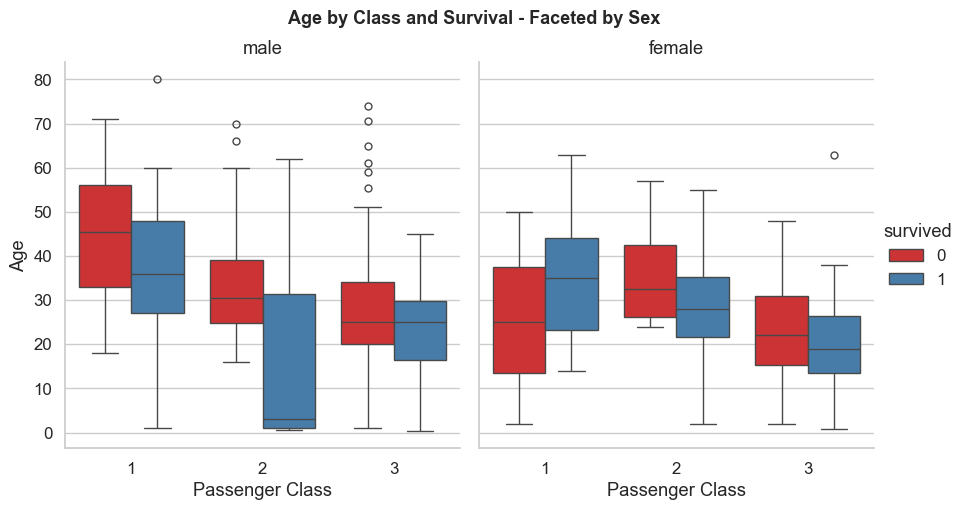

In [12]:
# CATPLOT: Faceted boxplots
# Age distribution by class, faceted by sex (male | female)

g = sns.catplot(
    data=titanic,
    x='pclass',
    y='age',
    hue='survived',
    col='sex',           # one chart per sex
    kind='box',          # which categorical plot type
    palette='Set1',
    height=5,
    aspect=0.9
)

g.set_axis_labels('Passenger Class', 'Age')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Age by Class and Survival - Faceted by Sex', fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day19_charts/8_catplot_faceted.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\1115217419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\1115217419.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.catplot(


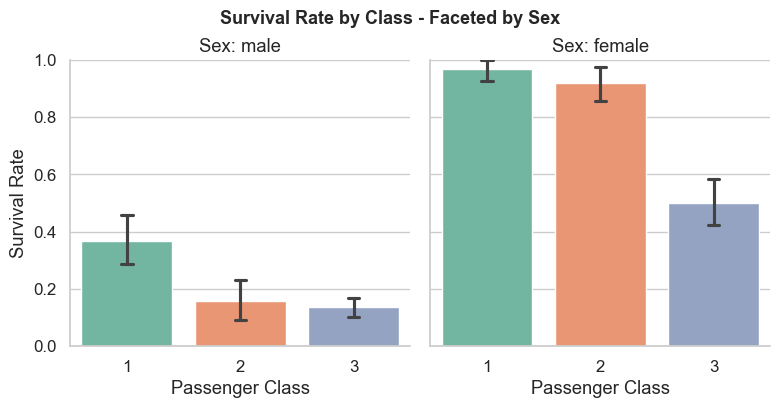

In [13]:
# CATPLOT: Survival rate by class faceted by sex using barplot

g = sns.catplot(
    data=titanic,
    x='pclass',
    y='survived',
    col='sex',
    kind='bar',
    palette='Set2',
    ci=95,
    capsize=0.1,
    height=4,
    aspect=1.0
)

g.set_axis_labels('Passenger Class', 'Survival Rate')
g.set_titles(col_template='Sex: {col_name}')
g.set(ylim=(0, 1))
g.figure.suptitle('Survival Rate by Class - Faceted by Sex', fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day19_charts/8b_catplot_bar_facet.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 3: Regression Plots

## What is a Regression Plot?

A regression plot draws a scatter plot and overlays a regression line (also called a trend line or best-fit line).

The regression line is computed using Ordinary Least Squares (OLS) - it finds the straight line that minimizes the sum of squared distances from all points to the line.

The shaded area around the line is the 95% confidence interval of the regression line. It tells you: we are 95% confident that the true regression line falls within this shaded band.

### When to Use Regression Plots:

- When you suspect a linear relationship between two numerical variables
- When you want to show the trend in data without just showing all the noisy points
- As a first step before running actual regression models

If the regression line fits poorly (points are far from the line), the relationship is not linear.

---

## regplot vs lmplot

These two functions look similar but have a critical difference:

`regplot` is an axis-level function:
- Returns a Matplotlib axes
- Can be placed inside plt.subplots()
- Does NOT support hue= parameter directly

`lmplot` is a figure-level function:
- Returns a FacetGrid
- Creates its own figure
- Supports hue=, col=, row= for grouping and faceting
- This is the function you want when you need to compare regression lines by group

RuntimeError: `logistic=True` requires statsmodels, an optional dependency, to be installed.

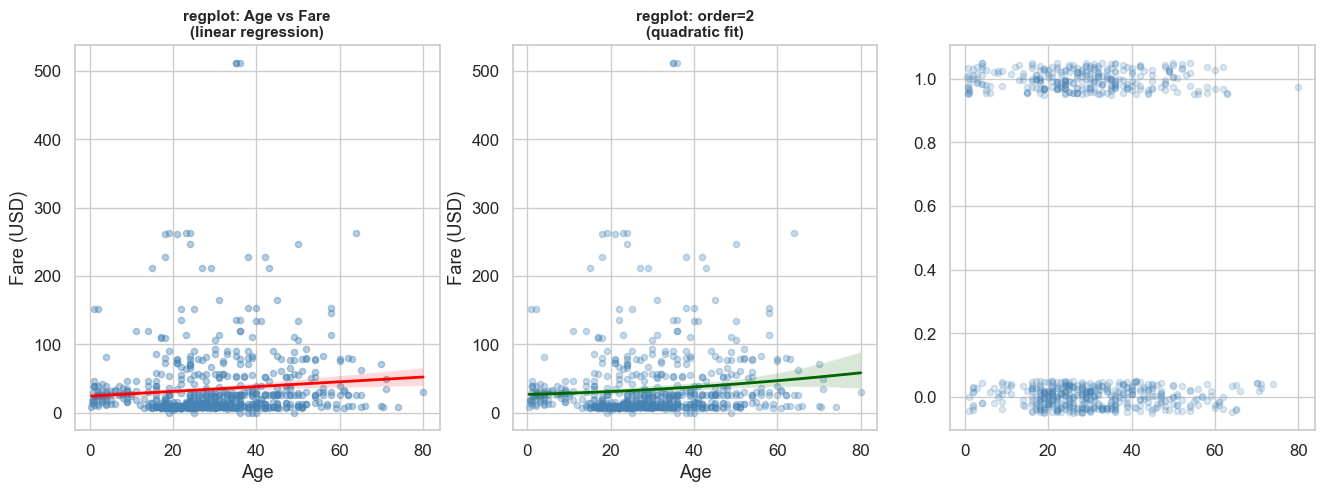

In [14]:
# REGPLOT: Axis-level regression

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: linear regression (default)
sns.regplot(
    data=titanic,
    x='age',
    y='fare',
    scatter_kws={'alpha': 0.4, 's': 20},  # kwargs passed to scatter
    line_kws={'color': 'red', 'linewidth': 2},  # kwargs passed to the line
    ci=95,               # confidence interval percentage
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('regplot: Age vs Fare\n(linear regression)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare (USD)')

# Middle: polynomial regression (order=2 means quadratic curve)
sns.regplot(
    data=titanic.dropna(subset=['age']),
    x='age',
    y='fare',
    order=2,             # fit a quadratic (degree 2) polynomial instead of line
    scatter_kws={'alpha': 0.3, 's': 20},
    line_kws={'color': 'darkgreen', 'linewidth': 2},
    color='steelblue',
    ax=axes[1]
)
axes[1].set_title('regplot: order=2\n(quadratic fit)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare (USD)')

# Right: logistic regression (for binary y variable)
# survived is 0 or 1 - classic binary outcome
# logistic=True fits a logistic curve (S-shape between 0 and 1)
sns.regplot(
    data=titanic.dropna(subset=['age']),
    x='age',
    y='survived',
    logistic=True,       # fits logistic regression for 0/1 outcome
    scatter_kws={'alpha': 0.2, 's': 20},
    line_kws={'color': 'red', 'linewidth': 2},
    color='steelblue',
    y_jitter=0.05,       # adds tiny vertical jitter to 0/1 points so they are visible
    ax=axes[2]
)
axes[2].set_title('regplot: logistic=True\n(binary outcome)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Probability of Survival')

plt.suptitle('regplot Variations: Linear, Polynomial, Logistic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/9_regplot.png', dpi=150, bbox_inches='tight')
plt.show()

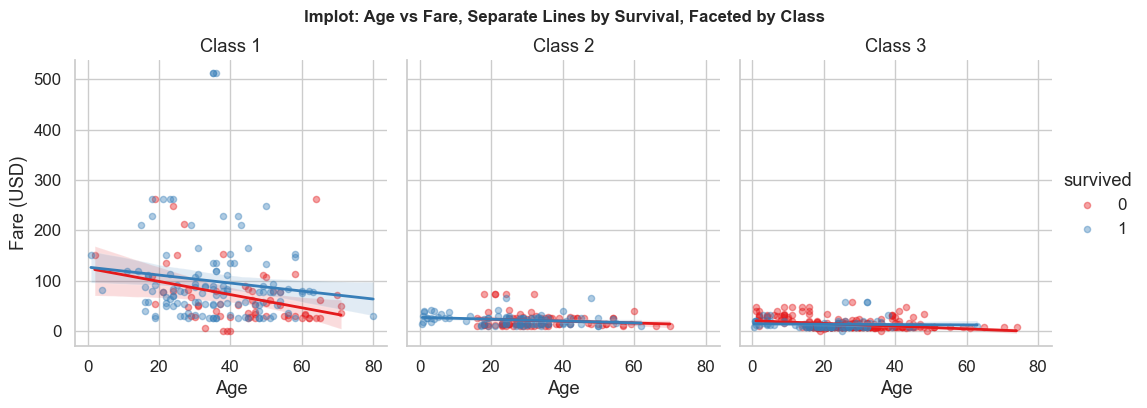

In [15]:
# LMPLOT: Figure-level regression with hue and faceting
# lmplot lets you draw separate regression lines for each group (hue)
# and split into multiple charts (col/row)

g = sns.lmplot(
    data=titanic.dropna(subset=['age', 'fare']),
    x='age',
    y='fare',
    hue='survived',      # separate regression line per survival status
    col='pclass',        # separate chart per class
    palette='Set1',
    scatter_kws={'alpha': 0.4, 's': 20},
    line_kws={'linewidth': 2},
    ci=95,
    height=4,
    aspect=0.9,
    col_wrap=3
)

g.set_axis_labels('Age', 'Fare (USD)')
g.set_titles(col_template='Class {col_name}')
g.figure.suptitle('lmplot: Age vs Fare, Separate Lines by Survival, Faceted by Class',
                   fontsize=12, fontweight='bold', y=1.02)

plt.savefig('day19_charts/10_lmplot.png', dpi=150, bbox_inches='tight')
plt.show()

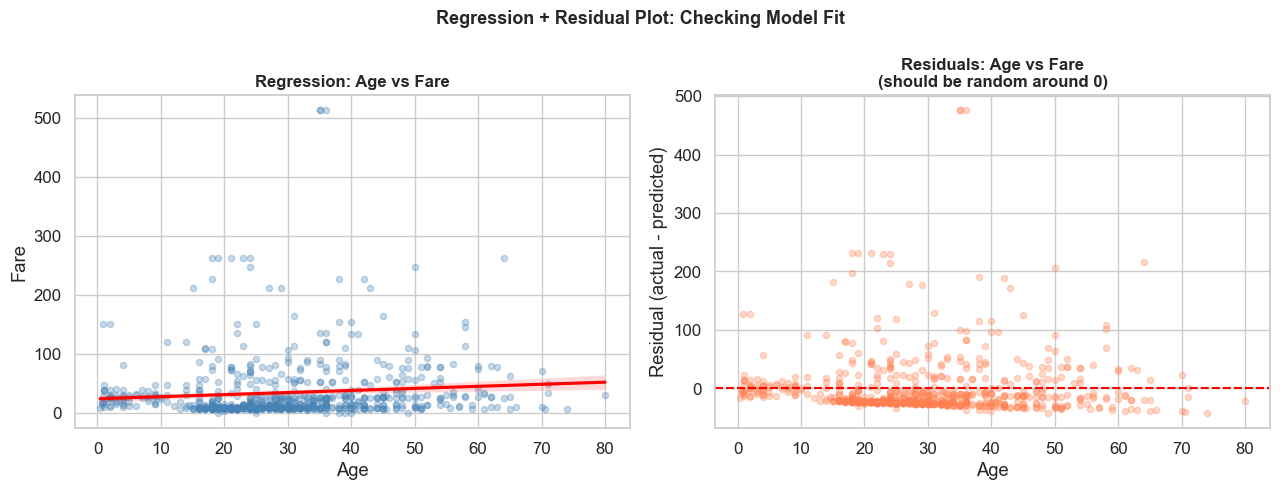

Observation: Residuals are NOT random - they fan out as age increases.
This is called heteroscedasticity. The variance of errors is not constant.
Suggests linear regression is not the best model here.


In [16]:
# RESIDPLOT: Plotting regression residuals
# Residuals = actual y value - predicted y value from the regression line
# A good linear regression should have residuals scattered randomly around 0
# If residuals show a pattern, the linear model is not appropriate

titanic_clean = titanic.dropna(subset=['age', 'fare'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: regression line
sns.regplot(data=titanic_clean, x='age', y='fare',
            scatter_kws={'alpha': 0.3, 's': 20},
            line_kws={'color': 'red'}, color='steelblue', ax=axes[0])
axes[0].set_title('Regression: Age vs Fare', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare')

# Right: residual plot
# Horizontal line at y=0 is the reference
# Points should scatter randomly above and below 0
# A pattern (curve, funnel shape) means the model is missing something
sns.residplot(
    data=titanic_clean,
    x='age',
    y='fare',
    scatter_kws={'alpha': 0.3, 's': 20},
    color='coral',
    ax=axes[1]
)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuals: Age vs Fare\n(should be random around 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Residual (actual - predicted)')

plt.suptitle('Regression + Residual Plot: Checking Model Fit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day19_charts/11_residplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Residuals are NOT random - they fan out as age increases.')
print('This is called heteroscedasticity. The variance of errors is not constant.')
print('Suggests linear regression is not the best model here.')

---

# Part 4: FacetGrid - Manual Grid with Full Control

## What is FacetGrid?

When you use `relplot`, `displot`, or `catplot`, they internally create a FacetGrid and then call the appropriate plot function on each cell.

FacetGrid lets you do this manually. You create the grid yourself, then use `g.map()` to call any function on each cell.

### Why Use FacetGrid Directly?

When the figure-level functions do not give you enough control, or when you want to call a custom function on each cell, or when you want to mix different plot types on different cells.

### The Workflow:

1. Create the grid: `g = sns.FacetGrid(data, col=, row=, hue=, height=, aspect=)`
2. Map a function to every cell: `g.map(sns.histplot, 'column_name')`
3. Add legend if needed: `g.add_legend()`

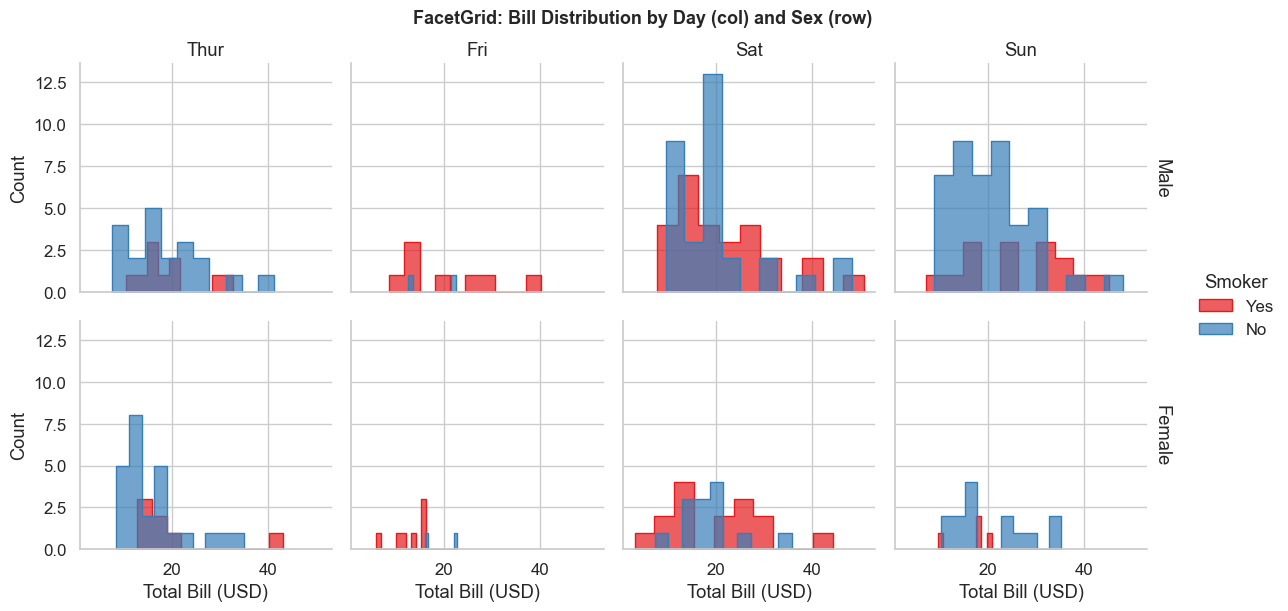

In [17]:
# FACETGRID: Manual grid creation

# Create a grid: columns = day, rows = sex
# Each cell will show the distribution of total_bill for that day+sex combo
g = sns.FacetGrid(
    tips,
    col='day',
    row='sex',
    hue='smoker',        # color coding within each cell
    height=3,
    aspect=1.0,
    palette='Set1',
    margin_titles=True   # puts row labels on the right margin instead of each cell
)

# g.map() calls the given function on each facet
# positional arguments after the function are the column names to use
# keyword arguments are passed directly to the function
g.map(sns.histplot, 'total_bill', bins=10, alpha=0.7, element='step')
g.add_legend(title='Smoker')
g.set_axis_labels('Total Bill (USD)', 'Count')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.figure.suptitle('FacetGrid: Bill Distribution by Day (col) and Sex (row)', 
                   fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day19_charts/12_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()

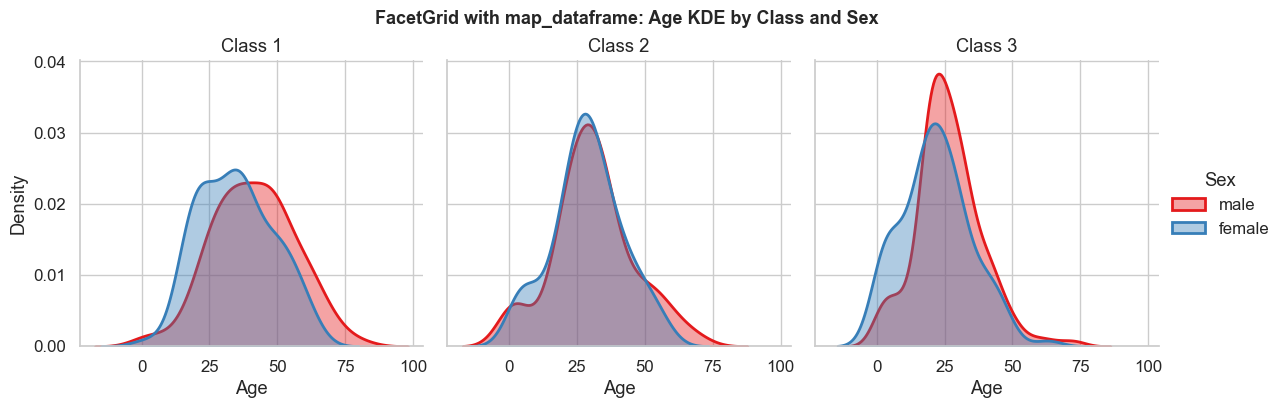

In [18]:
# FACETGRID with map_dataframe: when function needs data= and column names
# Some Seaborn functions need data= as a keyword, not positional
# Use g.map_dataframe() in that case

g2 = sns.FacetGrid(
    titanic.dropna(subset=['age']),
    col='pclass',
    hue='sex',
    height=4,
    aspect=1.0,
    palette='Set1'
)

# map_dataframe passes the subset of data AND column names to the function
g2.map_dataframe(sns.kdeplot, x='age', fill=True, alpha=0.4, linewidth=2)
g2.add_legend(title='Sex')
g2.set_axis_labels('Age', 'Density')
g2.set_titles(col_template='Class {col_name}')
g2.figure.suptitle('FacetGrid with map_dataframe: Age KDE by Class and Sex',
                    fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day19_charts/12b_facetgrid_map_dataframe.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 5: Pairplot - The EDA Shortcut

## What is a Pairplot?

A pairplot creates a grid of scatter plots for every pair of numerical variables in your dataset. It is a complete look at all pairwise relationships in one command.

For a dataset with n numerical columns, pairplot creates an n x n grid:
- Off-diagonal cells: scatter plots of column i vs column j
- Diagonal cells: distribution of each variable with itself (KDE or histogram)

For Iris: 4 numerical columns = 4x4 = 16 cells = 12 scatter plots + 4 diagonal distributions.

### Why Pairplot is Interview Gold:

Pairplot on the Iris dataset immediately shows that `petal_length` and `petal_width` perfectly separate the three species. This is what makes Iris the classic ML classification example. Any interviewer asking about your EDA process will be impressed if you show pairplot and can explain what it reveals.

### The hue Parameter in Pairplot:

With `hue='species'`, each species gets a different color. Now the scatter plots show you whether species are separable in each pair of dimensions. If the color clusters do not overlap, those features are good for classification.

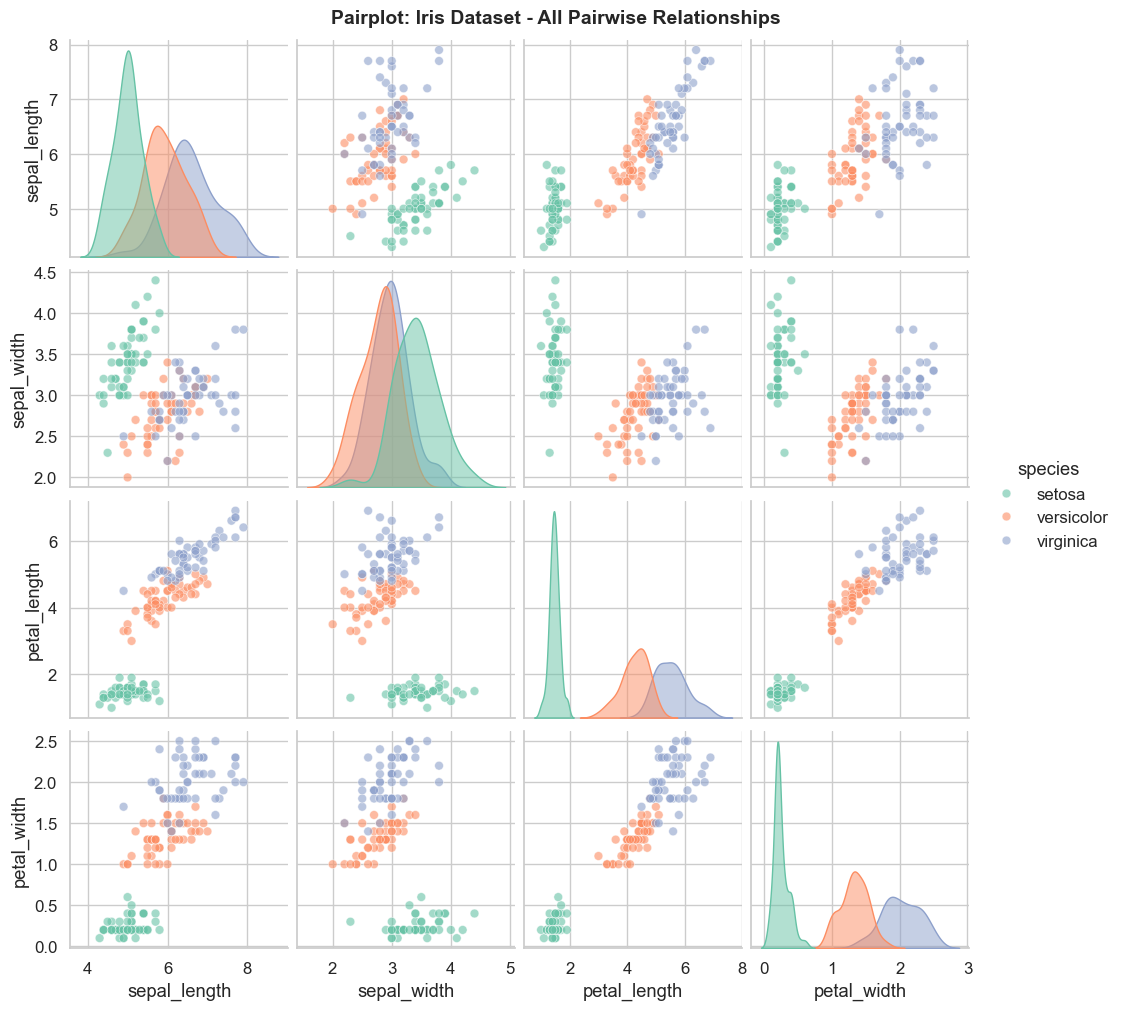

Key insight from this pairplot:
petal_length vs petal_width: three species form completely separate clusters.
This means these two features alone are enough to classify iris species.
sepal_width: poor separator (all species overlap significantly).


In [19]:
# PAIRPLOT on Iris dataset

# Basic pairplot with hue
g = sns.pairplot(
    iris,
    hue='species',           # color by species
    palette='Set2',
    diag_kind='kde',         # diagonal: KDE (smooth distribution curve)
                             # alternative: 'hist' for histogram
    plot_kws={'alpha': 0.6, 's': 40},  # kwargs for off-diagonal scatter
    diag_kws={'fill': True, 'alpha': 0.5}  # kwargs for diagonal KDE
)

g.figure.suptitle('Pairplot: Iris Dataset - All Pairwise Relationships',
                   fontsize=14, fontweight='bold', y=1.01)

plt.savefig('day19_charts/13_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight from this pairplot:')
print('petal_length vs petal_width: three species form completely separate clusters.')
print('This means these two features alone are enough to classify iris species.')
print('sepal_width: poor separator (all species overlap significantly).')

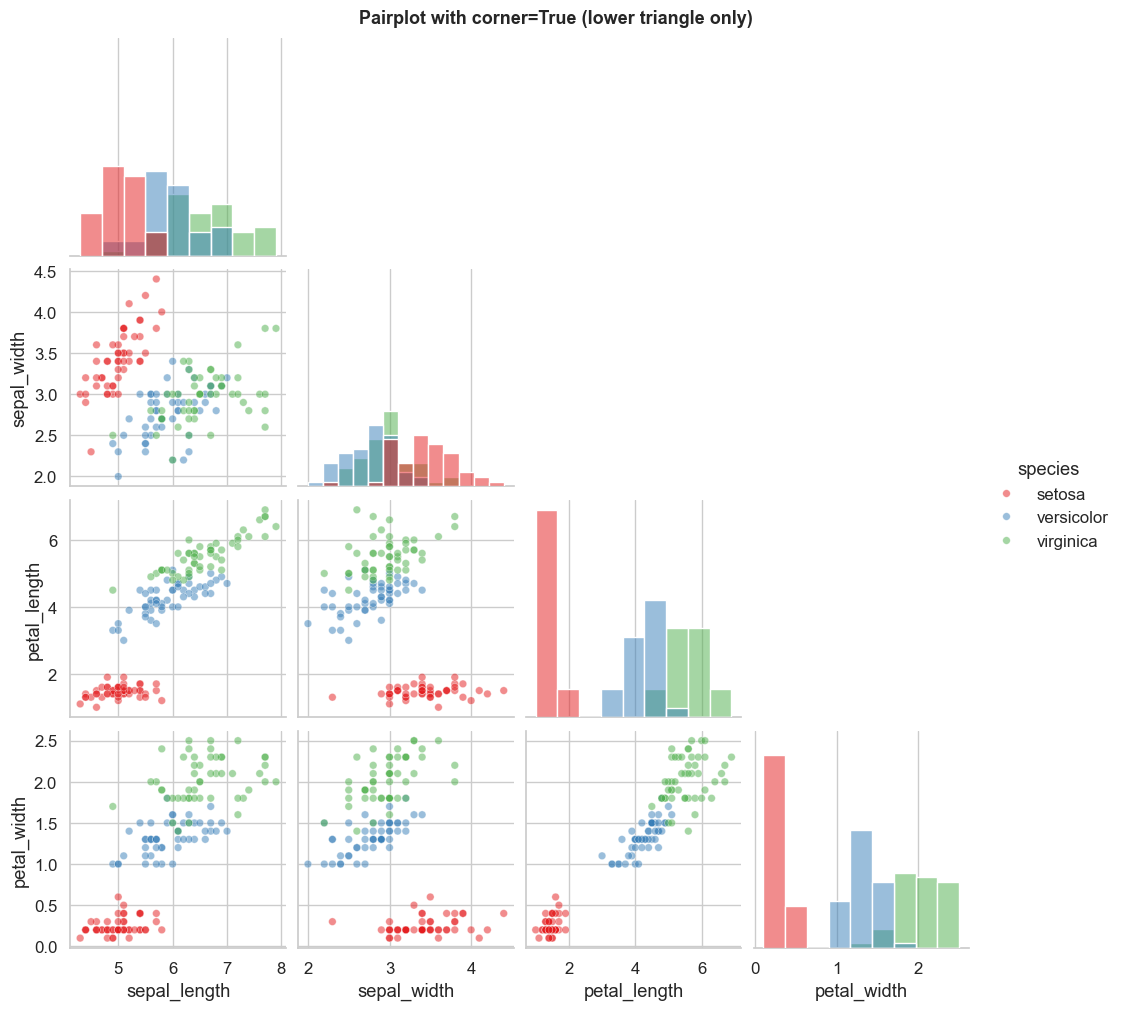

In [20]:
# PAIRPLOT with diag_kind='hist' and corner=True
# corner=True: only plots the lower triangle (no duplication)
# Saves space when you have many columns

g = sns.pairplot(
    iris,
    hue='species',
    palette='Set1',
    diag_kind='hist',        # histogram on diagonal
    corner=True,             # only lower triangle - no duplicate plots
    plot_kws={'alpha': 0.5, 's': 30}
)

g.figure.suptitle('Pairplot with corner=True (lower triangle only)', fontsize=13, fontweight='bold', y=1.01)

plt.savefig('day19_charts/13b_pairplot_corner.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 6: PairGrid - Customizable Pairplot

## PairGrid vs Pairplot

Pairplot is convenient but you cannot customize which plot type goes where.

PairGrid gives you full control:
- `g.map_diag()` - what to plot on the diagonal
- `g.map_upper()` - what to plot in the upper triangle
- `g.map_lower()` - what to plot in the lower triangle

This lets you create an information-rich grid:
- Diagonal: distributions (histplot or kdeplot)
- Upper triangle: KDE contours (showing density)
- Lower triangle: scatter plots (showing individual points)

The `vars=` parameter lets you choose which columns to include. Without it, all numerical columns are used.

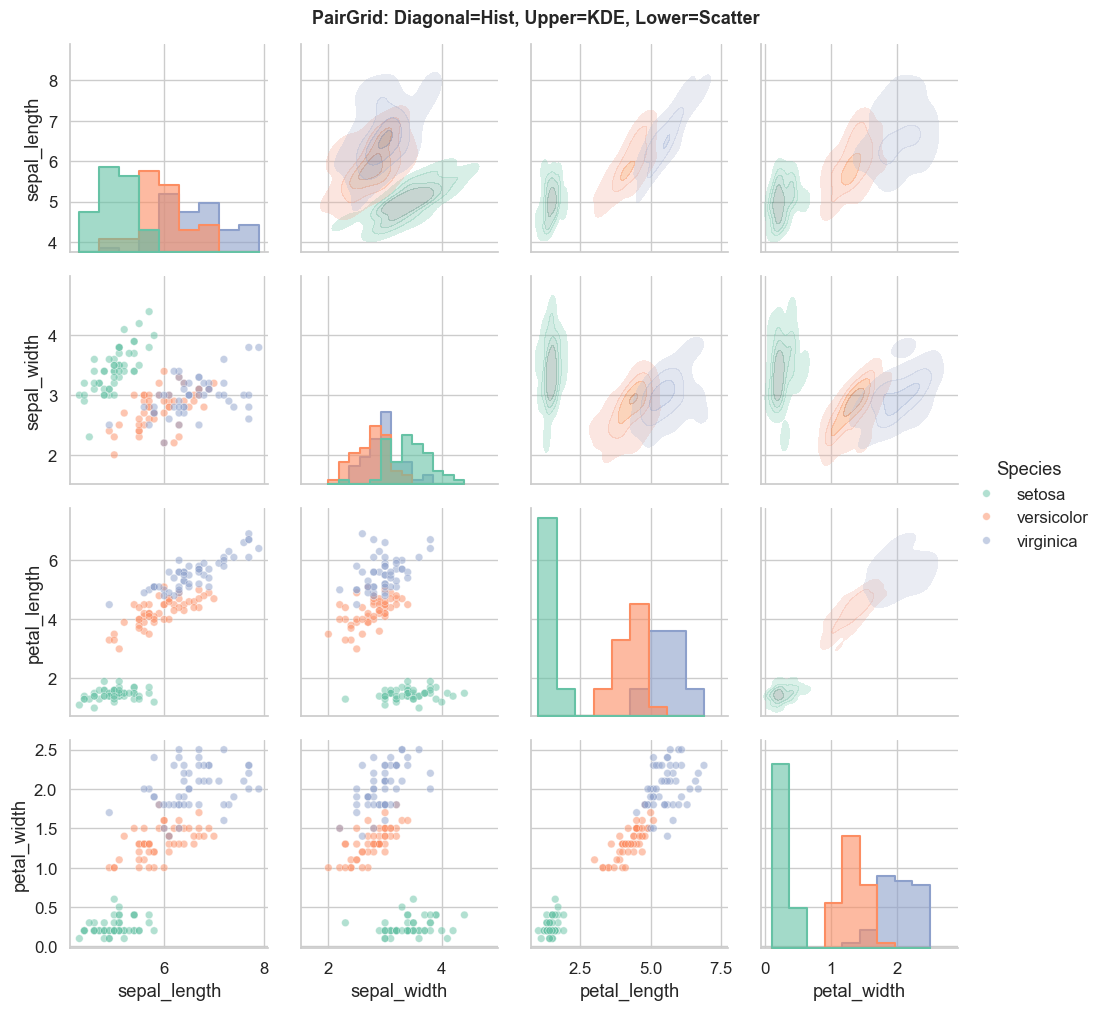

In [21]:
# PAIRGRID: Full custom control

g = sns.PairGrid(
    iris,
    vars=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],  # which columns
    hue='species',
    palette='Set2',
    height=2.5
)

# Diagonal: histogram for each variable
g.map_diag(sns.histplot, alpha=0.6, element='step', linewidth=1.5)

# Upper triangle: KDE density contours
g.map_upper(sns.kdeplot, fill=True, alpha=0.3, levels=5)

# Lower triangle: scatter plot
g.map_lower(sns.scatterplot, alpha=0.5, s=30)

g.add_legend(title='Species')
g.figure.suptitle('PairGrid: Diagonal=Hist, Upper=KDE, Lower=Scatter',
                   fontsize=13, fontweight='bold', y=1.01)

plt.savefig('day19_charts/14_pairgrid.png', dpi=150, bbox_inches='tight')
plt.show()

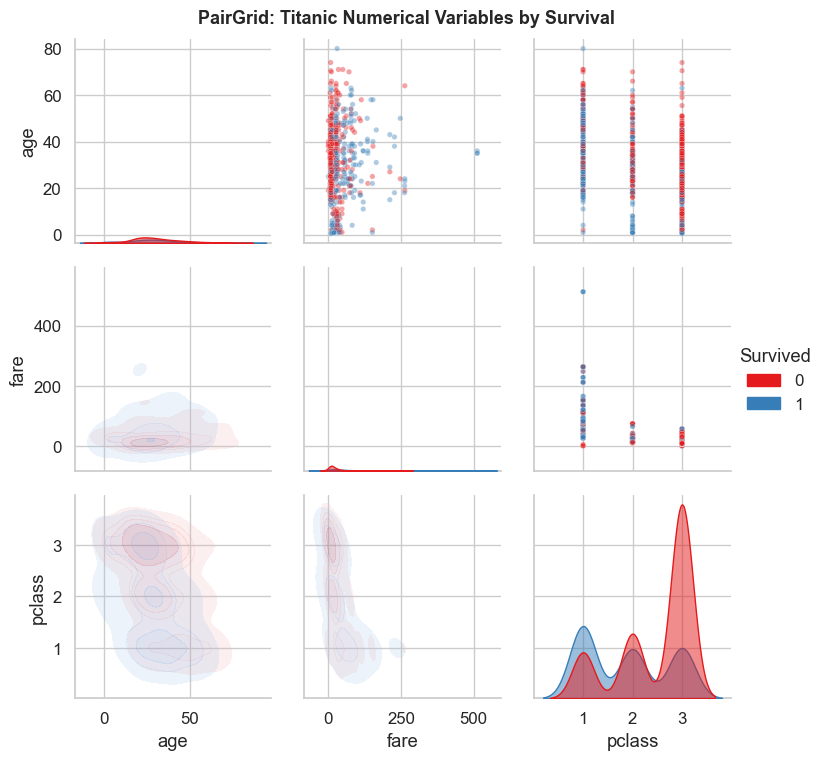

In [22]:
# PairGrid with Titanic - select only numerical columns

titanic_num = titanic[['age', 'fare', 'pclass', 'survived']].dropna()

g = sns.PairGrid(
    titanic_num,
    hue='survived',
    palette='Set1',
    height=2.5
)

g.map_diag(sns.kdeplot, fill=True, alpha=0.5)
g.map_upper(sns.scatterplot, alpha=0.4, s=15)
g.map_lower(sns.kdeplot, fill=True, alpha=0.2, levels=5)

g.add_legend(title='Survived')
g.figure.suptitle('PairGrid: Titanic Numerical Variables by Survival',
                   fontsize=13, fontweight='bold', y=1.01)

plt.savefig('day19_charts/14b_pairgrid_titanic.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 7: Jointplot - Bivariate with Marginal Distributions

## What is a Jointplot?

A jointplot shows two things:
1. The CENTER: the relationship between two variables (scatter, KDE, histogram)
2. The MARGINS: the individual distribution of each variable (on the top and right edges)

The marginal distributions are small plots on the axes of the main chart. This is extremely information-rich:
- You see the bivariate relationship in the center
- You see each variable's individual distribution in the margins
- All in one figure

### kind= parameter options:

- `kind='scatter'` - scatter in center, histogram in margins
- `kind='kde'` - 2D KDE in center, KDE in margins
- `kind='hist'` - 2D histogram in center, histogram in margins
- `kind='hex'` - hexagonal bin 2D histogram in center
- `kind='reg'` - regression line in center (like regplot)
- `kind='resid'` - residuals in center

With `hue=`, multiple groups are shown with different colors throughout (center and margins).

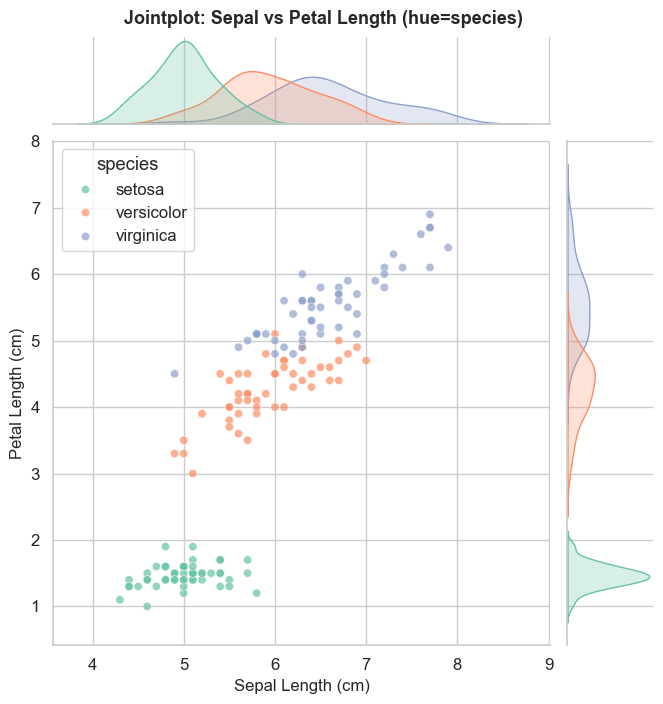

In [23]:
# JOINTPLOT: Iris - sepal_length vs petal_length

# kind='scatter' with hue
g = sns.jointplot(
    data=iris,
    x='sepal_length',
    y='petal_length',
    hue='species',       # hue works in jointplot - different colors per species
    kind='scatter',      # scatter in center, KDE in margins when hue is used
    palette='Set2',
    height=7,
    alpha=0.7
)

g.set_axis_labels('Sepal Length (cm)', 'Petal Length (cm)', fontsize=12)
g.figure.suptitle('Jointplot: Sepal vs Petal Length (hue=species)',
                   fontsize=13, fontweight='bold', y=1.01)

plt.savefig('day19_charts/15_jointplot_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

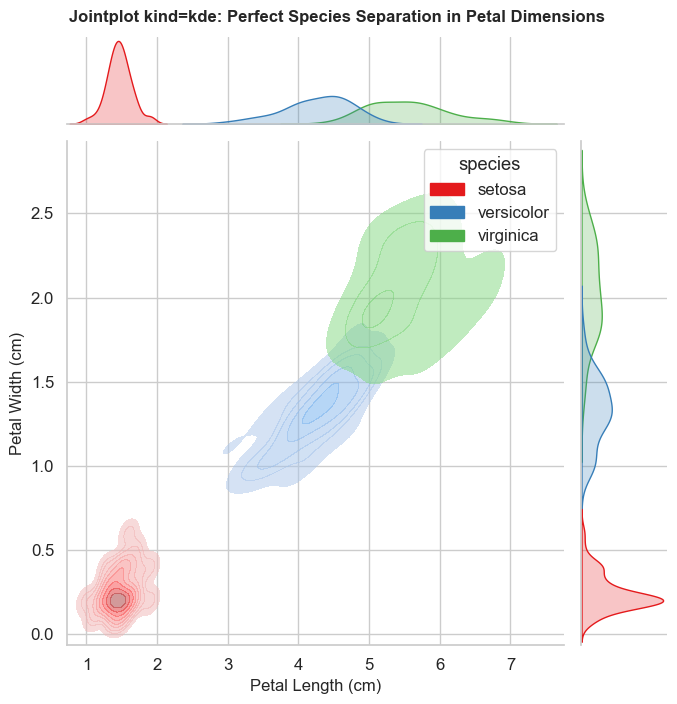

This chart reveals why Iris is the perfect ML classification dataset:
Setosa is completely separate. Versicolor and Virginica overlap slightly.


In [24]:
# JOINTPLOT: kind='kde' - smooth density everywhere

g = sns.jointplot(
    data=iris,
    x='petal_length',
    y='petal_width',
    hue='species',
    kind='kde',          # 2D KDE in center, 1D KDE in margins
    palette='Set1',
    height=7,
    fill=True,
    alpha=0.5
)

g.set_axis_labels('Petal Length (cm)', 'Petal Width (cm)', fontsize=12)
g.figure.suptitle('Jointplot kind=kde: Perfect Species Separation in Petal Dimensions',
                   fontsize=12, fontweight='bold', y=1.01)

plt.savefig('day19_charts/15b_jointplot_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('This chart reveals why Iris is the perfect ML classification dataset:')
print('Setosa is completely separate. Versicolor and Virginica overlap slightly.')

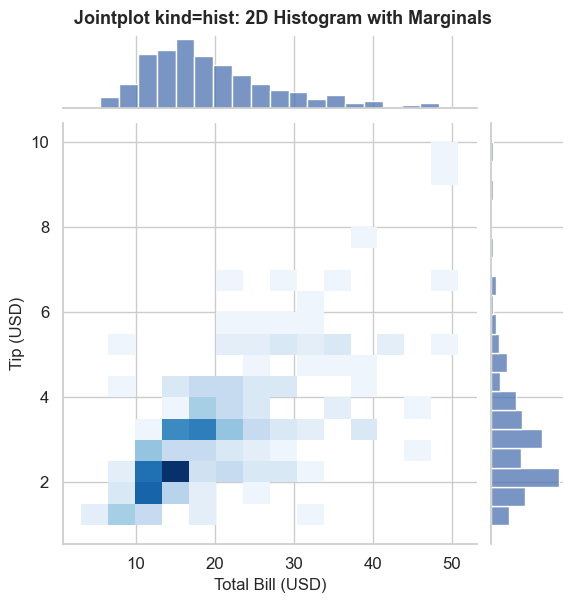

In [25]:
# JOINTPLOT: kind='hist' - 2D histogram

g = sns.jointplot(
    data=tips,
    x='total_bill',
    y='tip',
    kind='hist',
    cmap='Blues',
    height=6,
    marginal_kws={'bins': 20}  # kwargs for the marginal histograms
)

g.set_axis_labels('Total Bill (USD)', 'Tip (USD)', fontsize=12)
g.figure.suptitle('Jointplot kind=hist: 2D Histogram with Marginals',
                   fontsize=13, fontweight='bold', y=1.01)

plt.savefig('day19_charts/15c_jointplot_hist.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 8: JointGrid - Customizable Jointplot

## JointGrid vs Jointplot

Same relationship as PairGrid vs Pairplot. Jointplot is convenient but you cannot customize the center and marginal plots independently.

JointGrid gives you separate control:
- `g.plot_joint()` - controls what is in the CENTER
- `g.plot_marginals()` - controls what is on the MARGINS (top and right)

This lets you mix different plot types. For example:
- Center: scatter plot with regression line
- Margins: KDE curves

Or:
- Center: 2D KDE (density)
- Margins: histograms

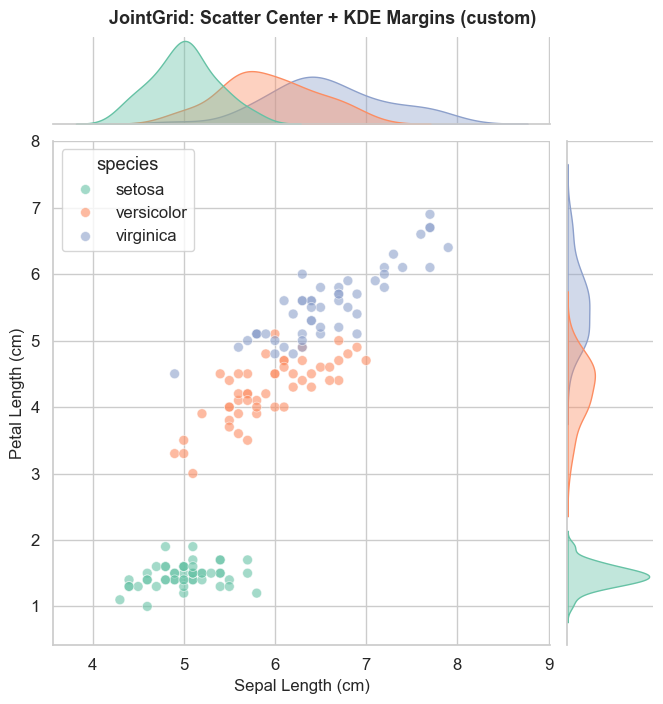

In [26]:
# JOINTGRID: Custom center and margins

g = sns.JointGrid(
    data=iris,
    x='sepal_length',
    y='petal_length',
    height=7
)

# Center: scatter with regression line
g.plot_joint(
    sns.scatterplot,
    data=iris,
    hue='species',
    palette='Set2',
    alpha=0.6,
    s=50
)

# Margins: KDE for each variable
# plot_marginals calls the function twice: once for x (top), once for y (right)
g.plot_marginals(
    sns.kdeplot,
    data=iris,
    hue='species',
    palette='Set2',
    fill=True,
    alpha=0.4
)

g.set_axis_labels('Sepal Length (cm)', 'Petal Length (cm)', fontsize=12)
g.figure.suptitle('JointGrid: Scatter Center + KDE Margins (custom)',
                   fontsize=13, fontweight='bold', y=1.01)

plt.savefig('day19_charts/16_jointgrid.png', dpi=150, bbox_inches='tight')
plt.show()

---

# GitHub File 1: categorical_regression.py - Titanic EDA

Titanic: (891, 15) rows. Survival rate: 38.38%


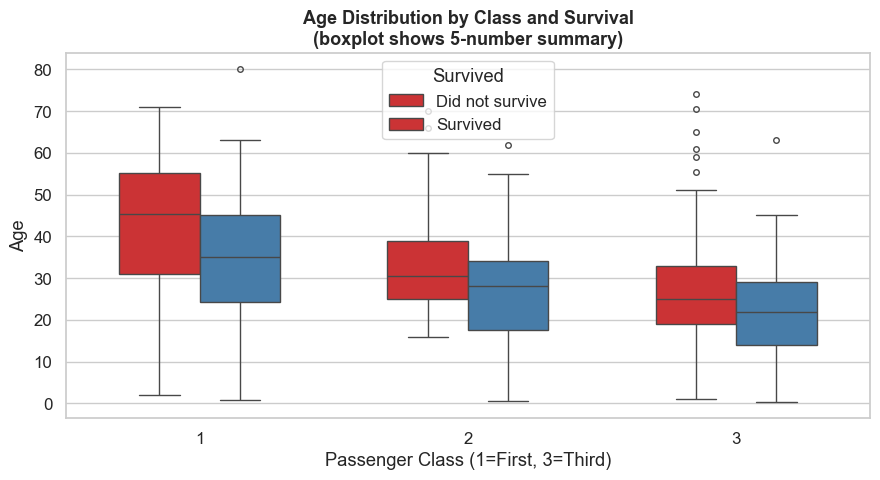

Chart 1 saved: Boxplot


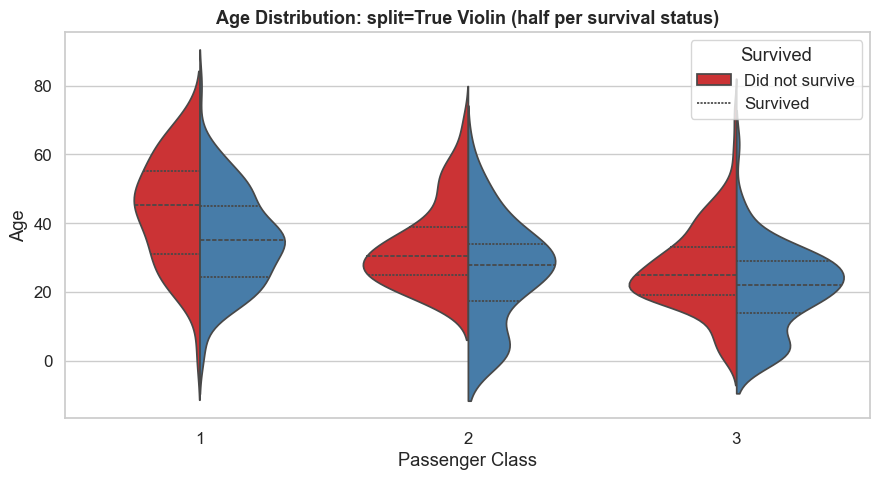

Chart 2 saved: Violinplot split=True


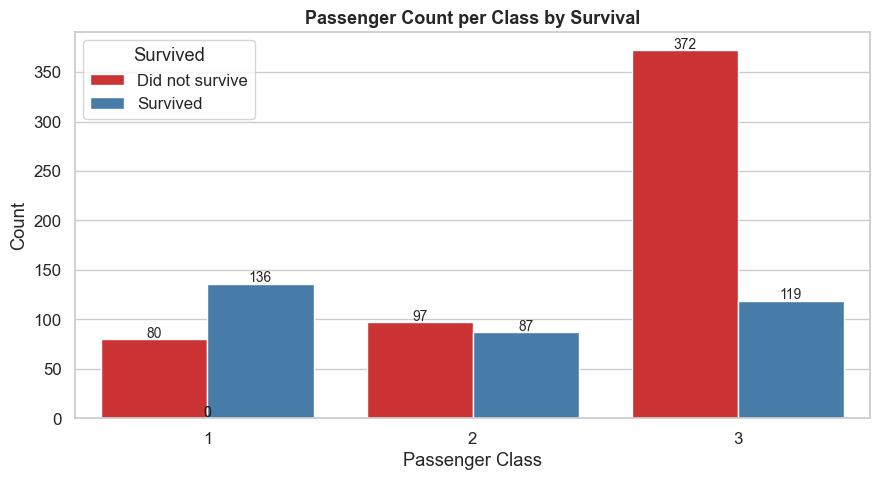

Chart 3 saved: Countplot


C:\Users\shaur\AppData\Local\Temp\ipykernel_1644\1892504402.py:73: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=titanic, x='pclass', y='fare', hue='sex',


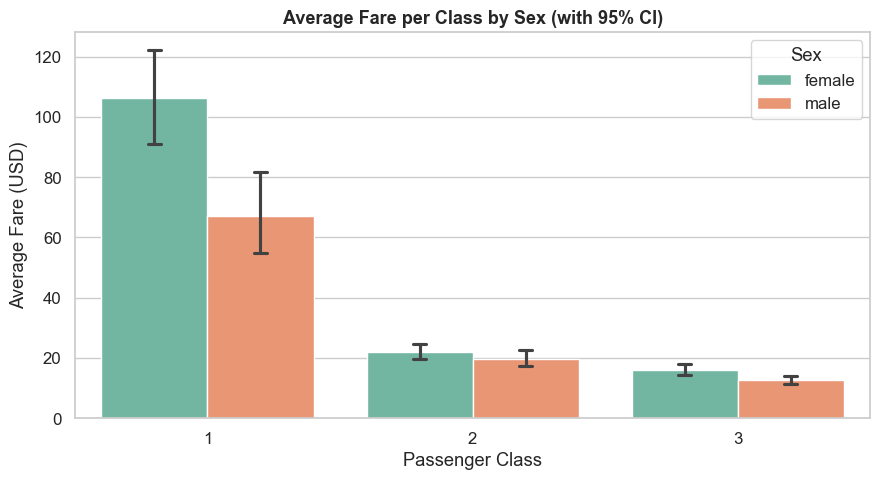

Chart 4 saved: Barplot


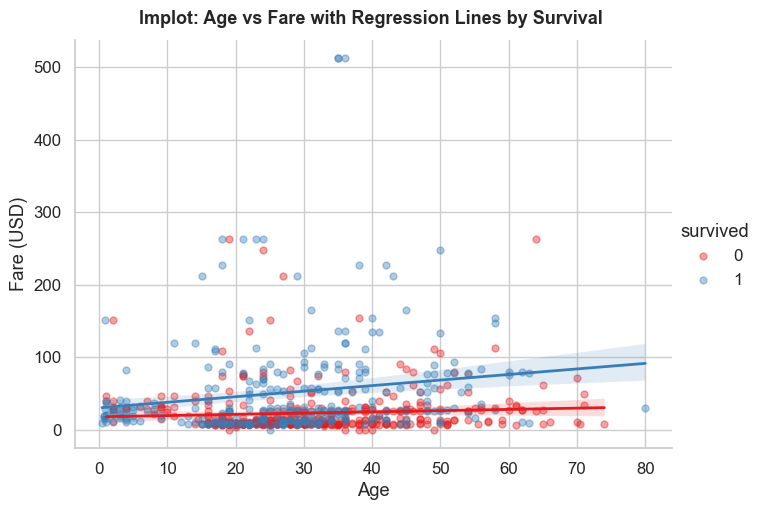

Chart 5 saved: lmplot
All Titanic charts saved!


In [27]:
# ============================================================
# day19_seaborn_advanced/categorical_regression.py
# Titanic EDA: Categorical + Regression Plots
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('day19_charts', exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

titanic = sns.load_dataset('titanic')
titanic_clean = titanic.dropna(subset=['age'])
print(f'Titanic: {titanic.shape} rows. Survival rate: {titanic["survived"].mean():.2%}')

# -------------------------------------------------------
# CHART 1: Boxplot - Age by Passenger Class
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=titanic, x='pclass', y='age', hue='survived',
            palette='Set1', width=0.6, fliersize=4, ax=ax)
ax.set_title('Age Distribution by Class and Survival\n(boxplot shows 5-number summary)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class (1=First, 3=Third)')
ax.set_ylabel('Age')
ax.legend(title='Survived', labels=['Did not survive', 'Survived'])
plt.tight_layout()
plt.savefig('day19_charts/github_titanic_1_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved: Boxplot')

# -------------------------------------------------------
# CHART 2: Violinplot - Age by Survived, split=True
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=titanic_clean, x='pclass', y='age',
               hue='survived', split=True, palette='Set1',
               inner='quart', ax=ax)
ax.set_title('Age Distribution: split=True Violin (half per survival status)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Age')
ax.legend(title='Survived', labels=['Did not survive', 'Survived'])
plt.tight_layout()
plt.savefig('day19_charts/github_titanic_2_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved: Violinplot split=True')

# -------------------------------------------------------
# CHART 3: Countplot - Class distribution, hue=survived
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=titanic, x='pclass', hue='survived',
              palette='Set1', edgecolor='white', ax=ax)
ax.set_title('Passenger Count per Class by Survival', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Count')
ax.legend(title='Survived', labels=['Did not survive', 'Survived'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height() + 2),
                ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('day19_charts/github_titanic_3_countplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved: Countplot')

# -------------------------------------------------------
# CHART 4: Barplot - Avg fare per class, hue=sex
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=titanic, x='pclass', y='fare', hue='sex',
            palette='Set2', ci=95, capsize=0.1, ax=ax)
ax.set_title('Average Fare per Class by Sex (with 95% CI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Average Fare (USD)')
ax.legend(title='Sex')
plt.tight_layout()
plt.savefig('day19_charts/github_titanic_4_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved: Barplot')

# -------------------------------------------------------
# CHART 5: lmplot - Age vs Fare, hue=survived
# -------------------------------------------------------
g = sns.lmplot(
    data=titanic_clean,
    x='age', y='fare',
    hue='survived',
    palette='Set1',
    scatter_kws={'alpha': 0.4, 's': 25},
    line_kws={'linewidth': 2},
    ci=95,
    height=5, aspect=1.4
)
g.set_axis_labels('Age', 'Fare (USD)')
g.figure.suptitle('lmplot: Age vs Fare with Regression Lines by Survival',
                   fontsize=13, fontweight='bold', y=1.02)
plt.savefig('day19_charts/github_titanic_5_lmplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved: lmplot')
print('All Titanic charts saved!')

---

# GitHub File 2: grid_plots.py - Iris Dataset Grid Plots

Iris: (150, 5) | Species: ['setosa' 'versicolor' 'virginica']


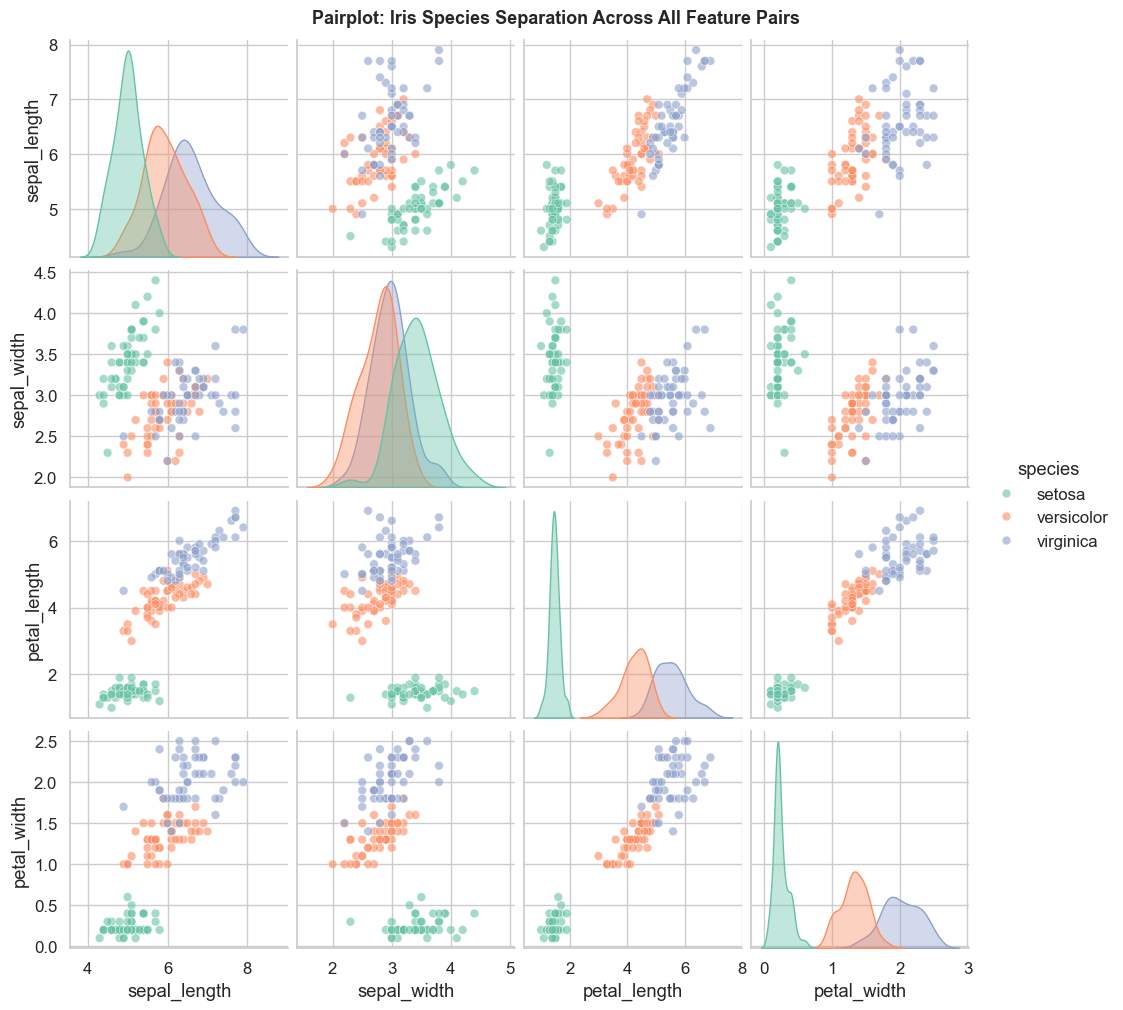

Chart 1 saved: Pairplot


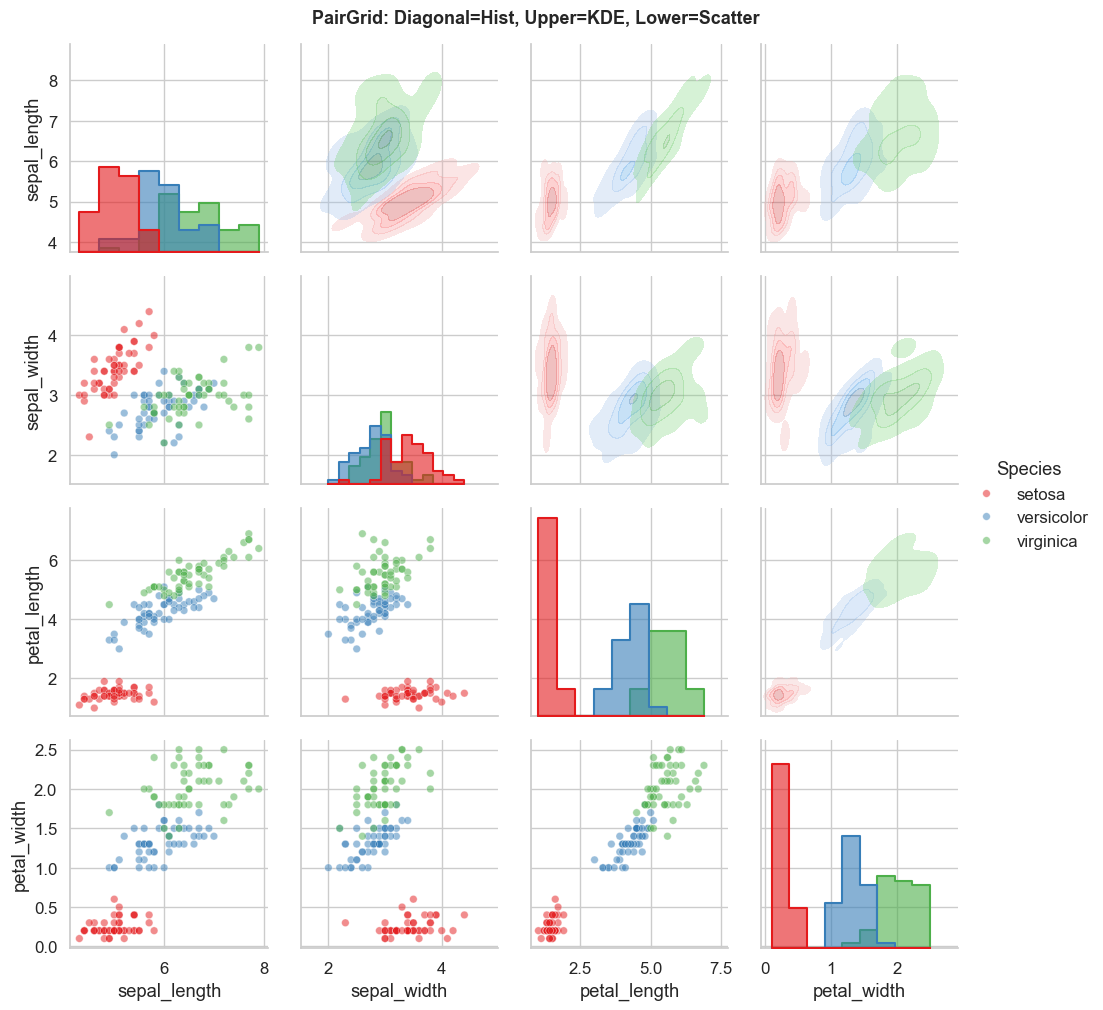

Chart 2 saved: PairGrid


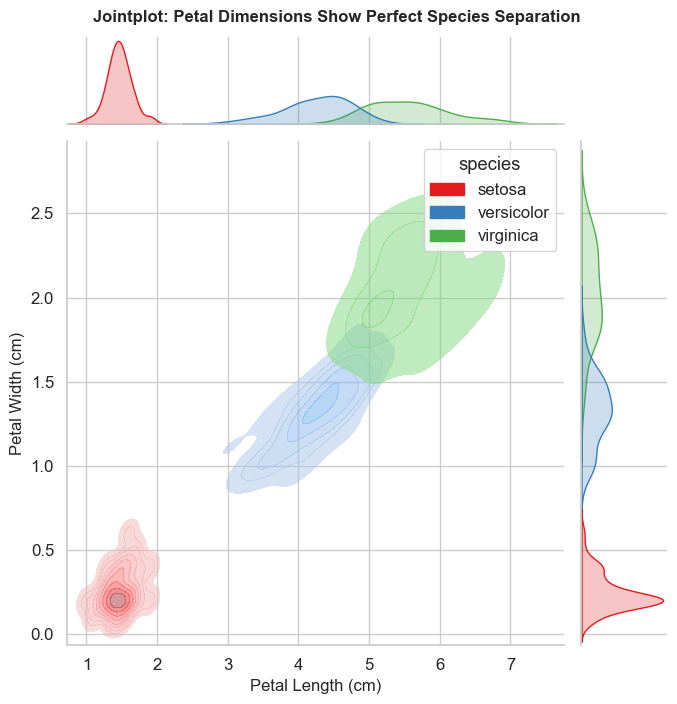

Chart 3 saved: Jointplot
All Iris grid charts saved!


In [28]:
# ============================================================
# day19_seaborn_advanced/grid_plots.py
# Iris Dataset: Pairplot, PairGrid, Jointplot
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('day19_charts', exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

iris = sns.load_dataset('iris')
print(f'Iris: {iris.shape} | Species: {iris["species"].unique()}')

# -------------------------------------------------------
# CHART 1: Pairplot - hue=species
# -------------------------------------------------------
g = sns.pairplot(
    iris,
    hue='species',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40},
    diag_kws={'fill': True, 'alpha': 0.4}
)
g.figure.suptitle('Pairplot: Iris Species Separation Across All Feature Pairs',
                   fontsize=13, fontweight='bold', y=1.01)
plt.savefig('day19_charts/github_iris_1_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved: Pairplot')

# -------------------------------------------------------
# CHART 2: PairGrid - map_diag, map_upper, map_lower
# -------------------------------------------------------
g = sns.PairGrid(iris, hue='species', palette='Set1', height=2.5)
g.map_diag(sns.histplot, alpha=0.6, element='step', linewidth=1.5)
g.map_upper(sns.kdeplot, fill=True, alpha=0.3, levels=5)
g.map_lower(sns.scatterplot, alpha=0.5, s=30)
g.add_legend(title='Species')
g.figure.suptitle('PairGrid: Diagonal=Hist, Upper=KDE, Lower=Scatter',
                   fontsize=13, fontweight='bold', y=1.01)
plt.savefig('day19_charts/github_iris_2_pairgrid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved: PairGrid')

# -------------------------------------------------------
# CHART 3: Jointplot - petal_length vs petal_width, kind='kde', hue=species
# -------------------------------------------------------
g = sns.jointplot(
    data=iris,
    x='petal_length',
    y='petal_width',
    hue='species',
    kind='kde',
    palette='Set1',
    height=7,
    fill=True,
    alpha=0.5
)
g.set_axis_labels('Petal Length (cm)', 'Petal Width (cm)', fontsize=12)
g.figure.suptitle('Jointplot: Petal Dimensions Show Perfect Species Separation',
                   fontsize=12, fontweight='bold', y=1.01)
plt.savefig('day19_charts/github_iris_3_jointplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved: Jointplot')
print('All Iris grid charts saved!')

---

# Complete Reference: Day 19 Cheat Sheet

---

## Categorical Plots Summary

```
Plot type    Function             What it shows
----------   -----------------    -------------------------------------------
stripplot    sns.stripplot()      All individual points (with jitter)
swarmplot    sns.swarmplot()      All points, non-overlapping beehive shape
boxplot      sns.boxplot()        5-number summary: min, Q1, median, Q3, max
violinplot   sns.violinplot()     Distribution shape (KDE) + boxplot inside
barplot      sns.barplot()        Mean of y per category + confidence interval
pointplot    sns.pointplot()      Mean as dot + connected by line + CI bars
countplot    sns.countplot()      Count of rows per category (no y= needed)
```

All of these plus `col=` and `row=` faceting: use `sns.catplot(kind='...')`

---

## Boxplot Components

```
Whisker top    -->  Q3 + 1.5 * IQR
Box top        -->  Q3 (75th percentile)
Line in box    -->  Median (50th percentile)
Box bottom     -->  Q1 (25th percentile)
Whisker bottom -->  Q1 - 1.5 * IQR
Dots outside   -->  Outliers
IQR            =    Q3 - Q1 (the box height)
```

---

## Violinplot inner= Options

```python
inner='box'      # mini boxplot inside violin (default)
inner='quartile' # three quartile lines inside
inner='point'    # individual data points inside
inner='stick'    # stick for each point
inner=None       # nothing inside, clean violin shape

split=True       # only when hue has exactly 2 categories
                 # left half = category 1, right half = category 2
```

---

## Regression Plots

```python
# axis-level: returns Matplotlib axes, no hue
sns.regplot(data=df, x=, y=,
    ci=95,             # confidence interval (None to remove)
    order=1,           # polynomial degree (1=linear, 2=quadratic)
    logistic=False,    # True for binary y variable
    scatter_kws={},    # dict of scatter styling
    line_kws={}        # dict of line styling
)

# figure-level: returns FacetGrid, supports hue, col, row
sns.lmplot(data=df, x=, y=,
    hue=,              # separate regression line per group
    col=, row=,        # faceting
    ci=95
)

# residual plot: checks model fit
sns.residplot(data=df, x=, y=)
# horizontal line at 0: add manually with ax.axhline(0)
# random scatter = good fit. Pattern = model problem.
```

---

## FacetGrid Manual Workflow

```python
g = sns.FacetGrid(df, col='cat_col', row='cat_col2',
                  hue='cat_col3', height=4, aspect=1.0)

# For functions that take positional column name arguments:
g.map(sns.histplot, 'numerical_col', bins=20, alpha=0.7)

# For functions that need data= keyword argument:
g.map_dataframe(sns.kdeplot, x='col1', fill=True)

g.add_legend()
g.set_axis_labels('x label', 'y label')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
```

---

## Pairplot vs PairGrid

```python
# Pairplot: one-liner, less control
sns.pairplot(df, hue='cat_col',
    diag_kind='kde',    # or 'hist'
    corner=True,        # lower triangle only
    plot_kws={},        # off-diagonal styling
    diag_kws={}         # diagonal styling
)

# PairGrid: full control
g = sns.PairGrid(df, hue='cat_col', vars=['col1','col2','col3'])
g.map_diag(sns.histplot)      # diagonal cells
g.map_upper(sns.kdeplot)      # upper triangle
g.map_lower(sns.scatterplot)  # lower triangle
g.add_legend()
```

---

## Jointplot vs JointGrid

```python
# Jointplot: one-liner
sns.jointplot(data=df, x='col1', y='col2',
    kind='scatter',   # 'scatter','kde','hist','hex','reg','resid'
    hue='cat_col',
    height=7
)

# JointGrid: separate control of center and margins
g = sns.JointGrid(data=df, x='col1', y='col2', height=7)
g.plot_joint(sns.scatterplot, hue='cat_col', alpha=0.6)
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.4)
```

---

## The 3 Critical Concepts (Interview Ready)

```
1. Figure-level vs Axis-level
   - Axis-level: returns axes, use inside plt.subplots(), no faceting
   - Figure-level: returns FacetGrid/JointGrid, creates own figure, supports col=/row=
   - Never mix: do not use catplot inside plt.subplots()

2. Pairplot on Iris = instant EDA credibility
   - Shows all pairwise relationships in one command
   - With hue=species: reveals which features separate the classes
   - petal_length and petal_width: perfect separation (great for ML)
   - sepal_width: poor separation (bad feature for classification)

3. hue= is the Seaborn superpower
   - Matplotlib: for loop + manual colors + manual legend = 15 lines
   - Seaborn: hue='column_name' = 1 parameter
   - Works in almost every plot: scatter, line, hist, kde, box, violin, bar, count
```

---